# ⚡ EV Intelligence Platform — Notebook 07
# Final Dashboard & Power BI Preparation

## Purpose

This is the **final dashboard notebook** for the EV Intelligence Platform.

It starts from the already cleaned and renamed real-world dataset:

`datas/cleaned/ev_cleaned.csv`

It does **not** assume that Notebook 06 created any `outputs/powerbi/fact_ev.csv` file.

### Workflow

```text
Cleaned EV Dataset
       ↓
Dashboard Validation
       ↓
Dashboard Feature Engineering
       ↓
KPI Layer
       ↓
Business Summary Tables
       ↓
Interactive Plotly Visualizations
       ↓
Dashboard Filters / Slicer Logic
       ↓
Executive Insights
       ↓
Power BI Export Package
       ↓
Final QA
```

### Dashboard pages

1. Executive Overview
2. EV Market Intelligence
3. Geographic Intelligence
4. EV Technology
5. Pricing & Vehicle Profile
6. Advanced Business Insights

> All metrics are calculated from the real cleaned dataset. No synthetic observations are created.


## 1. Project Paths

The notebook is stored inside:

```text
ev_project_v2-Data Analysis/
└── notebooks/
    └── 07_EV_Final_Dashboard_Build.ipynb
```

Therefore the project root is one level above the notebook.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# Project root
ROOT = Path("..").resolve()

# Existing cleaned data
DATA_DIR = ROOT / "datas"
CLEANED_DIR = DATA_DIR / "cleaned"
CLEANED_FILE = CLEANED_DIR / "ev_cleaned.csv"

# Output folders
OUTPUT_DIR = ROOT / "outputs"
DASH_DIR = OUTPUT_DIR / "dashboard"
POWERBI_DIR = OUTPUT_DIR / "powerbi"

# Create only output folders required by this notebook
DASH_DIR.mkdir(parents=True, exist_ok=True)
POWERBI_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", ROOT)
print("Cleaned data :", CLEANED_FILE)
print("Dashboard out:", DASH_DIR)
print("Power BI out :", POWERBI_DIR)

Project root : D:\ev_project_v2-Data Analysis
Cleaned data : D:\ev_project_v2-Data Analysis\datas\cleaned\ev_cleaned.csv
Dashboard out: D:\ev_project_v2-Data Analysis\outputs\dashboard
Power BI out : D:\ev_project_v2-Data Analysis\outputs\powerbi


## 2. Load the Cleaned Dataset

The dataset has already been cleaned and renamed in Notebook 01, so this notebook does not repeat the cleaning workflow.

In [3]:
if not CLEANED_FILE.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found:\n{CLEANED_FILE}"
    )

df = pd.read_csv(CLEANED_FILE)

print("✅ Cleaned EV dataset loaded")
print("Shape:", df.shape)
display(df.head())

✅ Cleaned EV dataset loaded
Shape: (150482, 17)


,VIN,County,City,State,Postal_Code,Model_Year,Make,Model,EV_Type,CAFV_Eligibility,Electric_Range,Base_MSRP,Vehicle_ID,Vehicle_Location,Electric_Utility,Census_Tract,Legislative_District
0,KM8K33AGXL,King,Seattle,WA,98103.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,258,0,249675142,POINT (-122.34301 47.659185),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033004800.0,43
1,1C4RJYB61N,King,Bothell,WA,98011.0,2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,233928502,POINT (-122.20578 47.762405),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033021804.0,1
2,1C4RJYD61P,Yakima,Yakima,WA,98908.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,25,0,229675939,POINT (-120.6027202 46.5965625),PACIFICORP,53077002900.0,14
3,5YJ3E1EA7J,King,Kirkland,WA,98034.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215,0,104714466,POINT (-122.209285 47.71124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033021903.0,45
4,WBY7Z8C5XJ,Thurston,Olympia,WA,98501.0,2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,97,0,185498386,POINT (-122.89692 47.043535),PUGET SOUND ENERGY INC,53067010700.0,22


## 3. Validate Required Columns

In [4]:
required_columns = [
    "VIN",
    "County",
    "City",
    "State",
    "Postal_Code",
    "Model_Year",
    "Make",
    "Model",
    "EV_Type",
    "CAFV_Eligibility",
    "Electric_Range",
    "Base_MSRP",
    "Legislative_District",
    "Vehicle_ID",
    "Vehicle_Location",
    "Electric_Utility",
    "Census_Tract"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )

print("✅ All required columns are available")

✅ All required columns are available


## 4. Dashboard Data Quality Check

In [5]:
quality = pd.DataFrame({
    "Column": df.columns,
    "Dtype": df.dtypes.astype(str).values,
    "Missing": df.isna().sum().values,
    "Missing_Pct": (
        df.isna().mean().mul(100).round(2).values
    ),
    "Unique": df.nunique(dropna=True).values
})

display(quality)

,Column,Dtype,Missing,Missing_Pct,Unique
0,VIN,str,0,0.0,9529
1,County,str,0,0.0,183
2,City,str,0,0.0,683
3,State,str,0,0.0,41
4,Postal_Code,object,0,0.0,1292
5,Model_Year,int64,0,0.0,22
6,Make,str,0,0.0,37
7,Model,str,0,0.0,127
8,EV_Type,str,0,0.0,2
9,CAFV_Eligibility,str,0,0.0,3


## 5. Duplicate Check

In [6]:
duplicate_rows = df.duplicated().sum()
duplicate_vins = df["VIN"].duplicated().sum()

print("Duplicate rows:", duplicate_rows)
print("Duplicate VIN values:", duplicate_vins)

Duplicate rows: 0
Duplicate VIN values: 140953


## 6. Create Dashboard Features

These are analytical fields derived from existing real observations. They do not create synthetic records.

In [7]:
# Vehicle count
df["Vehicle_Count"] = 1

# Vehicle age relative to latest observed model year
reference_year = int(df["Model_Year"].max())

df["Vehicle_Age"] = (
    reference_year - df["Model_Year"]
).clip(lower=0)

# Age segments
df["Age_Group"] = pd.cut(
    df["Vehicle_Age"],
    bins=[-1, 3, 6, 10, np.inf],
    labels=[
        "0–3 Years",
        "4–6 Years",
        "7–10 Years",
        "10+ Years"
    ]
)

# Range segments
df["Range_Group"] = pd.cut(
    df["Electric_Range"],
    bins=[-1, 50, 100, 200, 300, np.inf],
    labels=[
        "0–50",
        "51–100",
        "101–200",
        "201–300",
        "300+"
    ]
)

# MSRP segments
df["MSRP_Group"] = pd.cut(
    df["Base_MSRP"],
    bins=[-1, 30000, 50000, 75000, 100000, np.inf],
    labels=[
        "< $30K",
        "$30K–$50K",
        "$50K–$75K",
        "$75K–$100K",
        "$100K+"
    ]
)

print("✅ Dashboard features created")

✅ Dashboard features created


## 7. Feature Validation

In [8]:
feature_check = df[
    [
        "Model_Year",
        "Vehicle_Age",
        "Age_Group",
        "Electric_Range",
        "Range_Group",
        "Base_MSRP",
        "MSRP_Group"
    ]
].head(10)

display(feature_check)

,Model_Year,Vehicle_Age,Age_Group,Electric_Range,Range_Group,Base_MSRP,MSRP_Group
0,2020,4,4–6 Years,258,201–300,0,< $30K
1,2022,2,0–3 Years,25,0–50,0,< $30K
2,2023,1,0–3 Years,25,0–50,0,< $30K
3,2018,6,4–6 Years,215,201–300,0,< $30K
4,2018,6,4–6 Years,97,51–100,0,< $30K
5,2020,4,4–6 Years,266,201–300,0,< $30K
6,2017,7,7–10 Years,33,0–50,0,< $30K
7,2020,4,4–6 Years,291,201–300,0,< $30K
8,2018,6,4–6 Years,215,201–300,0,< $30K
9,2023,1,0–3 Years,0,0–50,0,< $30K


# 📊 Executive Dashboard Data Layer

## 8. Core KPI Calculations

In [9]:
kpis = pd.DataFrame({
    "KPI": [
        "Total Vehicles",
        "Manufacturers",
        "Models",
        "States",
        "Counties",
        "Cities",
        "EV Types",
        "Average Electric Range",
        "Median Electric Range",
        "Average Base MSRP",
        "Median Base MSRP",
        "Average Vehicle Age"
    ],
    "Value": [
        df["VIN"].nunique(),
        df["Make"].nunique(),
        df["Model"].nunique(),
        df["State"].nunique(),
        df["County"].nunique(),
        df["City"].nunique(),
        df["EV_Type"].nunique(),
        df["Electric_Range"].mean(),
        df["Electric_Range"].median(),
        df["Base_MSRP"].mean(),
        df["Base_MSRP"].median(),
        df["Vehicle_Age"].mean()
    ]
})

display(kpis)

,KPI,Value
0,Total Vehicles,9529.000000
1,Manufacturers,37.000000
2,Models,127.000000
3,States,41.000000
4,Counties,183.000000
5,Cities,683.000000
6,EV Types,2.000000
7,Average Electric Range,67.877839
8,Median Electric Range,18.000000
9,Average Base MSRP,1312.644735


## 9. Year-wise Market Summary

In [10]:
year_summary = (
    df.groupby("Model_Year", dropna=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          Avg_Range=("Electric_Range", "mean"),
          Median_Range=("Electric_Range", "median"),
          Avg_MSRP=("Base_MSRP", "mean")
      )
      .reset_index()
      .sort_values("Model_Year")
)

year_summary["YoY_Growth_Pct"] = (
    year_summary["Vehicle_Count"]
    .pct_change()
    .mul(100)
)

display(year_summary)

,Model_Year,Vehicle_Count,Avg_Range,Median_Range,Avg_MSRP,YoY_Growth_Pct
0,1997,1,39.000000,39.0,0.000000,NaN
1,1998,1,58.000000,58.0,0.000000,0.000000
2,1999,3,74.000000,74.0,0.000000,200.000000
3,2000,7,58.000000,58.0,0.000000,133.333333
4,2002,2,95.000000,95.0,0.000000,-71.428571
5,2003,1,95.000000,95.0,0.000000,-50.000000
6,2008,10,220.000000,220.0,98950.000000,900.000000
7,2010,13,226.875000,245.0,101205.625000,30.000000
8,2011,40,70.851759,73.0,958.542714,207.692308
9,2012,163,62.186160,35.0,5977.097367,307.500000


## 10. Manufacturer Summary

In [11]:
manufacturer_summary = (
    df.groupby("Make", dropna=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          Model_Count=("Model", "nunique"),
          Avg_Range=("Electric_Range", "mean"),
          Median_Range=("Electric_Range", "median"),
          Avg_MSRP=("Base_MSRP", "mean")
      )
      .reset_index()
      .sort_values("Vehicle_Count", ascending=False)
)

manufacturer_summary["Market_Share_Pct"] = (
    manufacturer_summary["Vehicle_Count"]
    / manufacturer_summary["Vehicle_Count"].sum()
    * 100
)

display(manufacturer_summary.head(20))

,Make,Vehicle_Count,Model_Count,Avg_Range,Median_Range,Avg_MSRP,Market_Share_Pct
31,TESLA,1303,5,90.296943,0.0,1648.601829,13.674048
35,VOLVO,943,7,15.633484,18.0,4785.930430,9.896107
10,FORD,814,8,13.023903,19.0,0.000000,8.542344
1,AUDI,779,11,53.517299,16.0,0.000000,8.175045
6,CHEVROLET,738,5,95.267670,53.0,0.000000,7.744779
4,BMW,724,11,38.163379,30.0,4154.123311,7.597859
13,HYUNDAI,524,8,23.982971,0.0,0.000000,5.499003
16,KIA,522,7,52.615682,26.0,3253.041304,5.478014
27,PORSCHE,375,4,46.597276,14.0,4294.066148,3.935355
25,NISSAN,365,2,84.724902,84.0,0.000000,3.830412


## 11. Model Summary

In [12]:
model_summary = (
    df.groupby(["Make", "Model"], dropna=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          Avg_Range=("Electric_Range", "mean"),
          Avg_MSRP=("Base_MSRP", "mean"),
          Avg_Age=("Vehicle_Age", "mean")
      )
      .reset_index()
      .sort_values("Vehicle_Count", ascending=False)
)

display(model_summary.head(20))

,Make,Model,Vehicle_Count,Avg_Range,Avg_MSRP,Avg_Age
106,TESLA,MODEL S,505,183.456182,14288.858232,6.893969
107,TESLA,MODEL X,444,155.539304,0.000000,4.512710
33,CHEVROLET,VOLT,444,45.358896,0.000000,8.637423
125,VOLVO,XC90,378,22.278994,4372.141119,3.501217
124,VOLVO,XC60,317,24.125395,12151.949420,2.952582
91,NISSAN,LEAF,310,86.716615,0.000000,7.370213
42,FORD,MUSTANG MACH-E,296,0.000000,0.000000,2.057656
62,KIA,NIRO,274,80.398122,0.000000,3.131085
20,BMW,I3,242,88.954617,0.000000,7.649974
118,VOLKSWAGEN,ID.4,227,0.000000,0.000000,1.887296


## 12. State Summary

In [13]:
state_summary = (
    df.groupby("State", dropna=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          Manufacturer_Count=("Make", "nunique"),
          Model_Count=("Model", "nunique"),
          Avg_Range=("Electric_Range", "mean"),
          Avg_MSRP=("Base_MSRP", "mean")
      )
      .reset_index()
      .sort_values("Vehicle_Count", ascending=False)
)

state_summary["Market_Share_Pct"] = (
    state_summary["Vehicle_Count"]
    / state_summary["Vehicle_Count"].sum()
    * 100
)

display(state_summary.head(20))

,State,Vehicle_Count,Manufacturer_Count,Model_Count,Avg_Range,Avg_MSRP,Market_Share_Pct
39,WA,9522,37,127,67.863135,1311.280829,96.591601
6,CA,88,16,28,69.195652,1998.913043,0.892676
38,VA,35,10,18,73.114286,0.000000,0.355042
21,MD,33,14,20,57.363636,3090.909091,0.334753
36,TX,20,8,12,80.350000,1749.750000,0.202881
15,IL,12,6,7,94.250000,3332.916667,0.121729
26,NC,12,4,6,40.692308,0.000000,0.121729
7,CO,11,6,10,90.727273,0.000000,0.111584
4,AZ,11,8,10,36.818182,0.000000,0.111584
11,FL,9,4,6,123.444444,0.000000,0.091296


## 13. County Summary

In [14]:
county_summary = (
    df.groupby(["State", "County"], dropna=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          Model_Count=("Model", "nunique")
      )
      .reset_index()
      .sort_values("Vehicle_Count", ascending=False)
)

display(county_summary.head(20))

,State,County,Vehicle_Count,Model_Count
172,WA,King,8123,123
186,WA,Snohomish,4492,117
182,WA,Pierce,4048,116
161,WA,Clark,3522,110
173,WA,Kitsap,2597,104
189,WA,Thurston,2531,100
187,WA,Spokane,2077,102
192,WA,Whatcom,2053,103
158,WA,Benton,1199,86
170,WA,Island,1182,87


## 14. City Summary

In [15]:
city_summary = (
    df.groupby(["State", "County", "City"], dropna=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          Model_Count=("Model", "nunique")
      )
      .reset_index()
      .sort_values("Vehicle_Count", ascending=False)
)

display(city_summary.head(20))

,State,County,City,Vehicle_Count,Model_Count
397,WA,King,Seattle,5836,118
364,WA,King,Bellevue,2677,108
276,WA,Clark,Vancouver,2587,101
393,WA,King,Redmond,2122,100
381,WA,King,Kirkland,2100,103
675,WA,Thurston,Olympia,1971,93
567,WA,Pierce,Tacoma,1854,97
394,WA,King,Renton,1834,97
395,WA,King,Sammamish,1806,99
605,WA,Snohomish,Bothell,1597,98


## 15. EV Type Summary

In [16]:
ev_type_summary = (
    df.groupby("EV_Type", dropna=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          Avg_Range=("Electric_Range", "mean"),
          Avg_MSRP=("Base_MSRP", "mean")
      )
      .reset_index()
      .sort_values("Vehicle_Count", ascending=False)
)

ev_type_summary["Share_Pct"] = (
    ev_type_summary["Vehicle_Count"]
    / ev_type_summary["Vehicle_Count"].sum()
    * 100
)

display(ev_type_summary)

,EV_Type,Vehicle_Count,Avg_Range,Avg_MSRP,Share_Pct
0,Battery Electric Vehicle (BEV),5341,78.608902,1146.231390,56.049953
1,Plug-in Hybrid Electric Vehicle (PHEV),4188,30.655471,1889.875427,43.950047


## 16. CAFV Eligibility Summary

In [17]:
cafv_summary = (
    df.groupby("CAFV_Eligibility", dropna=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          Avg_Range=("Electric_Range", "mean")
      )
      .reset_index()
      .sort_values("Vehicle_Count", ascending=False)
)

cafv_summary["Share_Pct"] = (
    cafv_summary["Vehicle_Count"]
    / cafv_summary["Vehicle_Count"].sum()
    * 100
)

display(cafv_summary)

,CAFV_Eligibility,Vehicle_Count,Avg_Range,Share_Pct
0,Clean Alternative Fuel Vehicle Eligible,3910,156.646026,41.032637
1,Eligibility unknown as battery range has not b...,3133,0.000000,32.878581
2,Not eligible due to low battery range,2486,19.815454,26.088782


## 17. Electric Utility Summary

In [18]:
utility_summary = (
    df.groupby("Electric_Utility", dropna=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          State_Count=("State", "nunique")
      )
      .reset_index()
      .sort_values("Vehicle_Count", ascending=False)
)

display(utility_summary.head(20))

,Electric_Utility,Vehicle_Count,State_Count
74,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),7113,3
57,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5976,1
73,PUGET SOUND ENERGY INC,5925,1
36,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,3476,1
19,BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,3006,1
75,PUGET SOUND ENERGY INC||PUD NO 1 OF WHATCOM CO...,1961,1
2,BONNEVILLE POWER ADMINISTRATION||AVISTA CORP||...,1448,1
31,BONNEVILLE POWER ADMINISTRATION||PUD 1 OF SNOH...,999,1
65,PACIFICORP,828,1
34,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF B...,808,1


## 18. Range Summary

In [19]:
range_summary = (
    df.groupby("Range_Group", observed=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          Avg_MSRP=("Base_MSRP", "mean")
      )
      .reset_index()
)

range_summary["Share_Pct"] = (
    range_summary["Vehicle_Count"]
    / range_summary["Vehicle_Count"].sum()
    * 100
)

display(range_summary)

,Range_Group,Vehicle_Count,Avg_MSRP,Share_Pct
0,0–50,7044,638.349340,73.921713
1,51–100,838,1299.533973,8.794207
2,101–200,462,379.903221,4.848358
3,201–300,1141,4060.174938,11.973974
4,300+,44,0.000000,0.461748


## 19. MSRP Summary

In [20]:
msrp_summary = (
    df.groupby("MSRP_Group", observed=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          Avg_Range=("Electric_Range", "mean")
      )
      .reset_index()
)

msrp_summary["Share_Pct"] = (
    msrp_summary["Vehicle_Count"]
    / msrp_summary["Vehicle_Count"].sum()
    * 100
)

display(msrp_summary)

,MSRP_Group,Vehicle_Count,Avg_Range,Share_Pct
0,< $30K,8965,66.570079,94.081226
1,$30K–$50K,169,59.888215,1.773533
2,$50K–$75K,307,159.539565,3.221744
3,$75K–$100K,51,64.228916,0.535208
4,$100K+,37,133.105263,0.388288


## 20. Vehicle Age Summary

In [21]:
age_summary = (
    df.groupby("Age_Group", observed=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          Avg_Range=("Electric_Range", "mean"),
          Avg_MSRP=("Base_MSRP", "mean")
      )
      .reset_index()
)

age_summary["Share_Pct"] = (
    age_summary["Vehicle_Count"]
    / age_summary["Vehicle_Count"].sum()
    * 100
)

display(age_summary)

,Age_Group,Vehicle_Count,Avg_Range,Avg_MSRP,Share_Pct
0,0–3 Years,5090,5.982471,0.000000,53.415888
1,4–6 Years,2207,188.307500,1591.168797,23.160877
2,7–10 Years,1723,101.489263,3100.124500,18.081646
3,10+ Years,509,75.896244,9771.110560,5.341589


# 🔀 Cross-Analysis & Business Intelligence Tables

## 21. State × EV Type Crosstab

In [22]:
state_evtype = pd.crosstab(
    df["State"],
    df["EV_Type"],
    values=df["VIN"],
    aggfunc="nunique"
).fillna(0)

display(state_evtype.head(20))

EV_Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
State,,
AK,1.0,0.0
AL,3.0,0.0
AP,1.0,0.0
AR,2.0,0.0
AZ,6.0,5.0
BC,2.0,0.0
CA,57.0,31.0
CO,9.0,2.0
CT,1.0,6.0


## 22. Manufacturer × EV Type Crosstab

In [23]:
make_evtype = pd.crosstab(
    df["Make"],
    df["EV_Type"],
    values=df["VIN"],
    aggfunc="nunique"
).fillna(0)

display(make_evtype.head(20))

EV_Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
Make,,
ALFA ROMEO,0.0,10.0
AUDI,524.0,255.0
AZURE DYNAMICS,6.0,0.0
BENTLEY,0.0,2.0
BMW,226.0,498.0
CADILLAC,38.0,54.0
CHEVROLET,294.0,444.0
CHRYSLER,0.0,219.0
FIAT,74.0,0.0


## 23. Year × EV Type Crosstab

In [24]:
year_evtype = pd.crosstab(
    df["Model_Year"],
    df["EV_Type"],
    values=df["VIN"],
    aggfunc="nunique"
).fillna(0)

display(year_evtype)

EV_Type,Battery Electric Vehicle (BEV),Plug-in Hybrid Electric Vehicle (PHEV)
Model_Year,,
1997,1.0,0.0
1998,1.0,0.0
1999,3.0,0.0
2000,7.0,0.0
2002,2.0,0.0
2003,1.0,0.0
2008,10.0,0.0
2010,11.0,2.0
2011,23.0,17.0


## 24. State × Manufacturer Summary

In [25]:
state_make = (
    df.groupby(["State", "Make"])
      .agg(Vehicle_Count=("VIN", "nunique"))
      .reset_index()
      .sort_values("Vehicle_Count", ascending=False)
)

display(state_make.head(30))

,State,Make,Vehicle_Count
180,WA,TESLA,1301
184,WA,VOLVO,941
159,WA,FORD,814
150,WA,AUDI,777
155,WA,CHEVROLET,738
153,WA,BMW,724
162,WA,HYUNDAI,523
165,WA,KIA,522
176,WA,PORSCHE,375
174,WA,NISSAN,365


## 25. Manufacturer Portfolio Matrix

In [26]:
portfolio_matrix = (
    df.groupby("Make", dropna=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          Model_Count=("Model", "nunique"),
          Avg_Range=("Electric_Range", "mean"),
          Median_Range=("Electric_Range", "median"),
          Avg_MSRP=("Base_MSRP", "mean"),
          Avg_Vehicle_Age=("Vehicle_Age", "mean")
      )
      .reset_index()
      .sort_values("Vehicle_Count", ascending=False)
)

display(portfolio_matrix.head(20))

,Make,Vehicle_Count,Model_Count,Avg_Range,Median_Range,Avg_MSRP,Avg_Vehicle_Age
31,TESLA,1303,5,90.296943,0.0,1648.601829,3.359393
35,VOLVO,943,7,15.633484,18.0,4785.930430,2.725113
10,FORD,814,8,13.023903,19.0,0.000000,5.098634
1,AUDI,779,11,53.517299,16.0,0.000000,3.516966
6,CHEVROLET,738,5,95.267670,53.0,0.000000,5.812490
4,BMW,724,11,38.163379,30.0,4154.123311,4.297717
13,HYUNDAI,524,8,23.982971,0.0,0.000000,1.897509
16,KIA,522,7,52.615682,26.0,3253.041304,2.977573
27,PORSCHE,375,4,46.597276,14.0,4294.066148,3.969844
25,NISSAN,365,2,84.724902,84.0,0.000000,7.223902


## 26. Top Model per Manufacturer

In [27]:
top_model_per_make = (
    model_summary
    .sort_values(
        ["Make", "Vehicle_Count"],
        ascending=[True, False]
    )
    .groupby("Make")
    .head(1)
    .reset_index(drop=True)
)

display(top_model_per_make.head(20))

,Make,Model,Vehicle_Count,Avg_Range,Avg_MSRP,Avg_Age
0,ALFA ROMEO,TONALE,10,33.000000,0.000000,0.000000
1,AUDI,E-TRON,204,122.696629,0.000000,3.416752
2,AZURE DYNAMICS,TRANSIT CONNECT ELECTRIC,6,56.000000,0.000000,12.555556
3,BENTLEY,BENTAYGA,1,17.000000,0.000000,3.000000
4,BMW,I3,242,88.954617,0.000000,7.649974
5,CADILLAC,ELR,43,37.571429,0.000000,9.480519
6,CHEVROLET,VOLT,444,45.358896,0.000000,8.637423
7,CHRYSLER,PACIFICA,219,32.242998,1771.163891,3.278198
8,FIAT,500,74,85.626551,0.000000,8.531017
9,FISKER,KARMA,10,33.000000,102000.000000,12.000000


# 📈 Interactive Visualization Layer

## 27. Visualization Libraries

In [28]:
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly is not installed.")

print("Plotly available:", PLOTLY_AVAILABLE)

Plotly available: True


## 28. Professional Dashboard Theme

In [29]:
THEMES = {
    "cream": {
        "paper": "#F7F1E8",
        "plot": "#FFFDF8",
        "text": "#2F2A25",
        "grid": "#D9D0C5"
    },
    "light": {
        "paper": "#FFFFFF",
        "plot": "#FFFFFF",
        "text": "#222222",
        "grid": "#DDDDDD"
    },
    "dark": {
        "paper": "#151515",
        "plot": "#202020",
        "text": "#F2F2F2",
        "grid": "#444444"
    }
}

ACTIVE_THEME = THEMES["cream"]


def apply_theme(fig, title=None):
    if title:
        fig.update_layout(title=title)

    fig.update_layout(
        paper_bgcolor=ACTIVE_THEME["paper"],
        plot_bgcolor=ACTIVE_THEME["plot"],
        font=dict(color=ACTIVE_THEME["text"]),
        margin=dict(l=50, r=30, t=70, b=50),
        hovermode="x unified"
    )

    fig.update_xaxes(
        showgrid=True,
        gridcolor=ACTIVE_THEME["grid"]
    )

    fig.update_yaxes(
        showgrid=True,
        gridcolor=ACTIVE_THEME["grid"]
    )

    return fig


print("✅ Cream dashboard theme configured")

✅ Cream dashboard theme configured


## 29. Chart — EV Population by Model Year

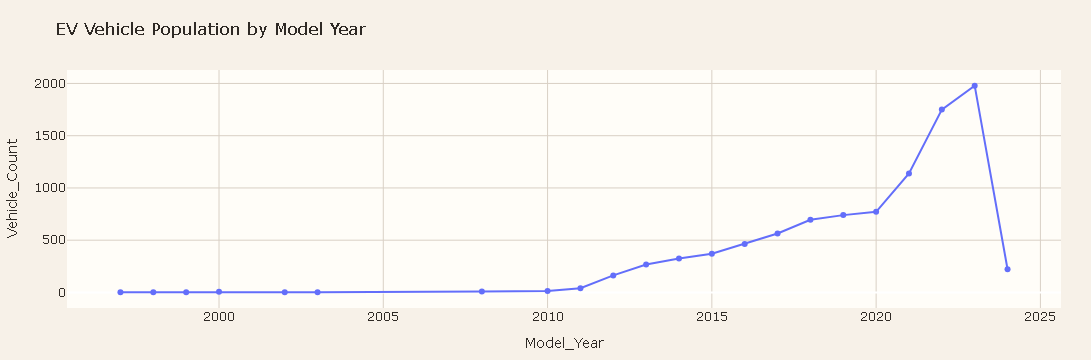

In [30]:
if PLOTLY_AVAILABLE:
    fig = px.line(
        year_summary,
        x="Model_Year",
        y="Vehicle_Count",
        markers=True,
        title="EV Vehicle Population by Model Year"
    )

    fig = apply_theme(fig)
    fig.show()

## 30. Chart — Top Manufacturers

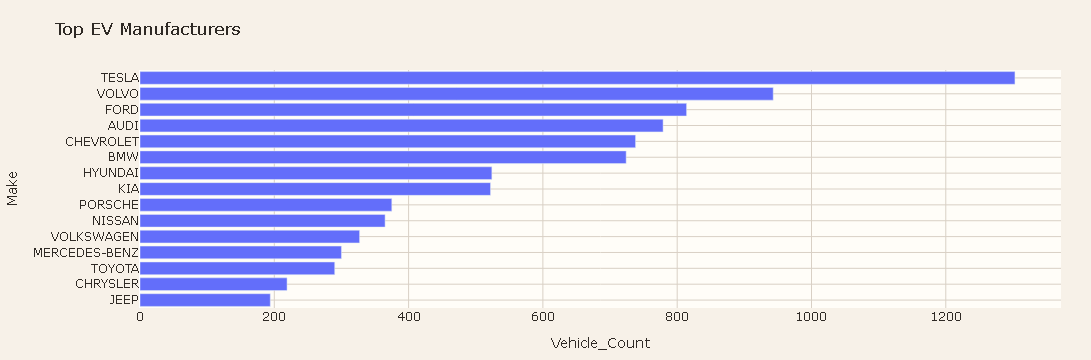

In [31]:
if PLOTLY_AVAILABLE:
    plot_data = (
        manufacturer_summary
        .head(15)
        .sort_values("Vehicle_Count")
    )

    fig = px.bar(
        plot_data,
        x="Vehicle_Count",
        y="Make",
        orientation="h",
        title="Top EV Manufacturers"
    )

    fig = apply_theme(fig)
    fig.show()

## 31. Chart — EV Type Mix

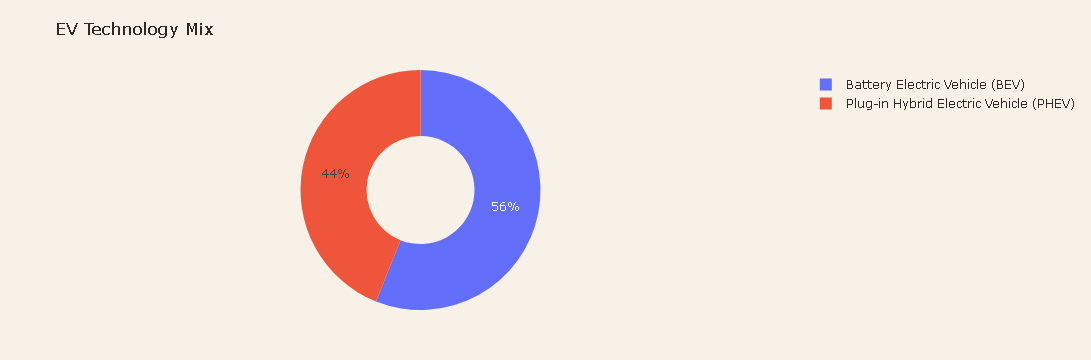

In [32]:
if PLOTLY_AVAILABLE:
    fig = px.pie(
        ev_type_summary,
        names="EV_Type",
        values="Vehicle_Count",
        hole=0.45,
        title="EV Technology Mix"
    )

    fig = apply_theme(fig)
    fig.show()

## 32. Chart — Leading States

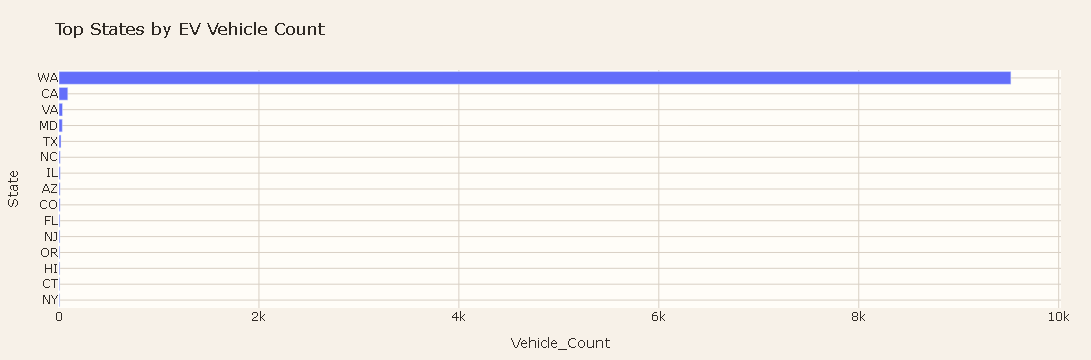

In [33]:
if PLOTLY_AVAILABLE:
    plot_data = (
        state_summary
        .head(15)
        .sort_values("Vehicle_Count")
    )

    fig = px.bar(
        plot_data,
        x="Vehicle_Count",
        y="State",
        orientation="h",
        title="Top States by EV Vehicle Count"
    )

    fig = apply_theme(fig)
    fig.show()

## 33. Chart — Electric Range Distribution

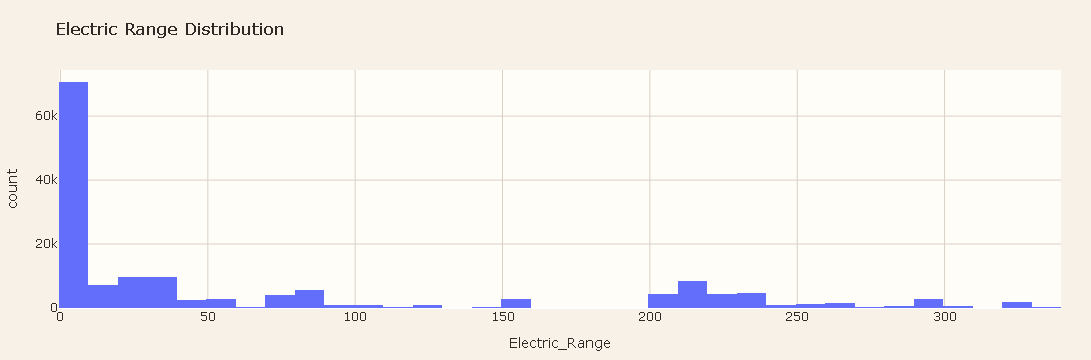

In [34]:
if PLOTLY_AVAILABLE:
    fig = px.histogram(
        df,
        x="Electric_Range",
        nbins=40,
        title="Electric Range Distribution"
    )

    fig = apply_theme(fig)
    fig.show()

## 34. Chart — MSRP Distribution

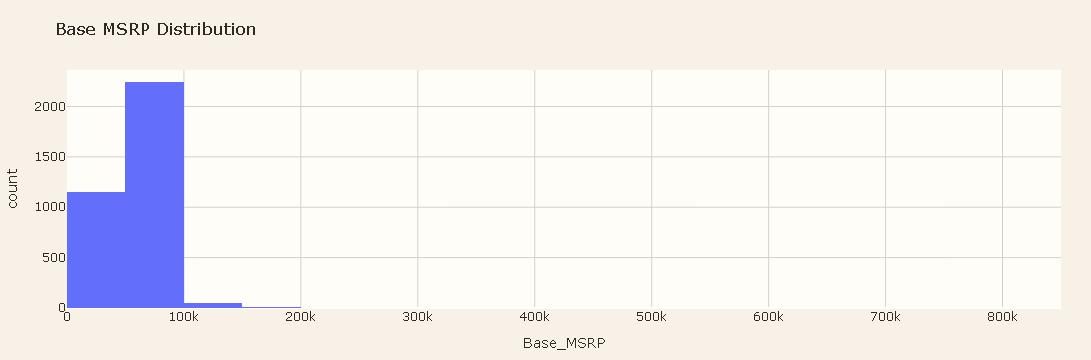

In [35]:
if PLOTLY_AVAILABLE:
    positive_msrp = df[df["Base_MSRP"] > 0]

    fig = px.histogram(
        positive_msrp,
        x="Base_MSRP",
        nbins=40,
        title="Base MSRP Distribution"
    )

    fig = apply_theme(fig)
    fig.show()

## 35. Chart — Range vs MSRP

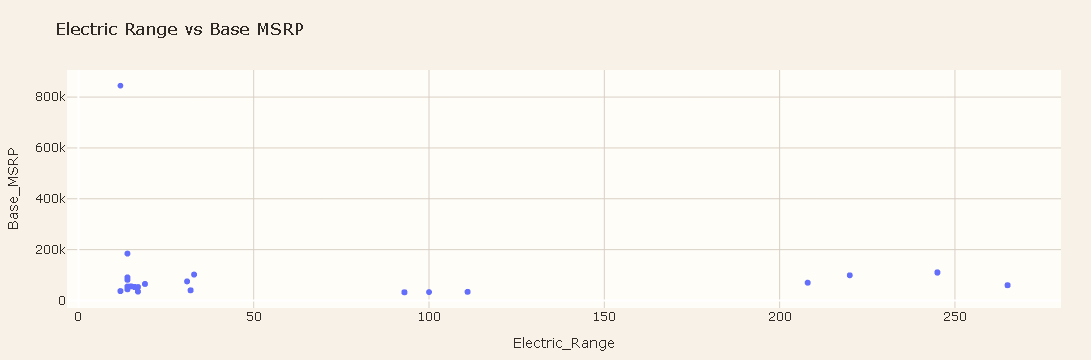

In [36]:
if PLOTLY_AVAILABLE:
    plot_data = df[
        (df["Electric_Range"] > 0) &
        (df["Base_MSRP"] > 0)
    ].copy()

    if len(plot_data) > 10000:
        plot_data = plot_data.sample(
            10000,
            random_state=42
        )

    fig = px.scatter(
        plot_data,
        x="Electric_Range",
        y="Base_MSRP",
        hover_data=[
            "Make",
            "Model",
            "Model_Year",
            "EV_Type"
        ],
        title="Electric Range vs Base MSRP"
    )

    fig = apply_theme(fig)
    fig.show()

## 36. Chart — Vehicle Age Segments

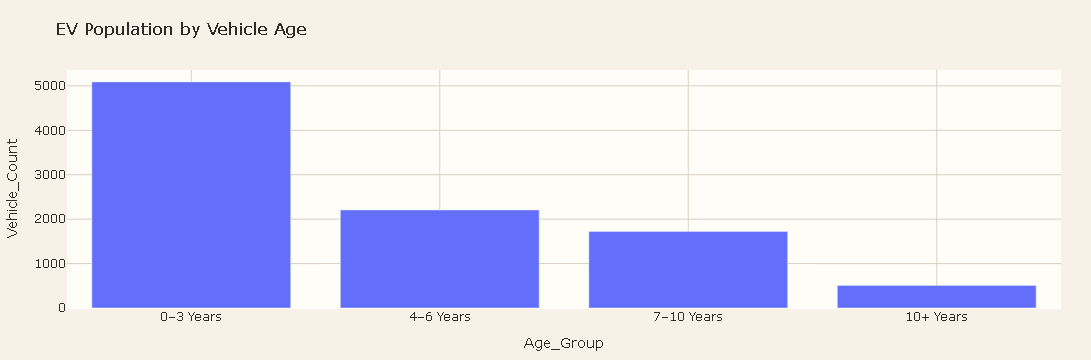

In [37]:
if PLOTLY_AVAILABLE:
    fig = px.bar(
        age_summary,
        x="Age_Group",
        y="Vehicle_Count",
        title="EV Population by Vehicle Age"
    )

    fig = apply_theme(fig)
    fig.show()

## 37. Chart — Range Segments

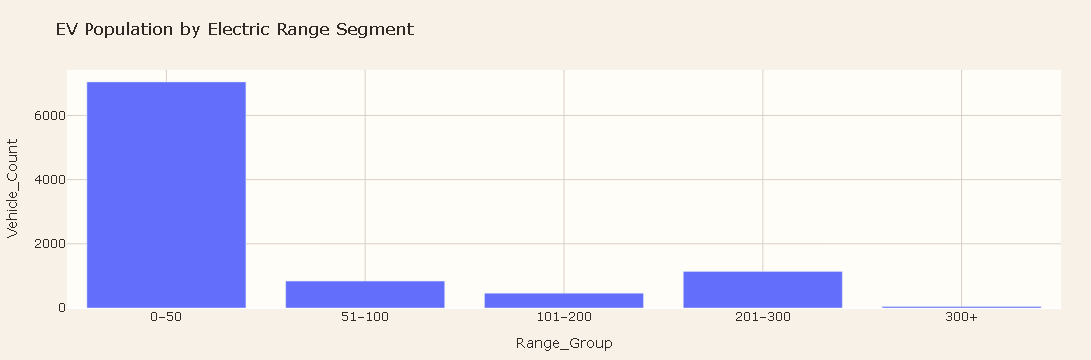

In [38]:
if PLOTLY_AVAILABLE:
    fig = px.bar(
        range_summary,
        x="Range_Group",
        y="Vehicle_Count",
        title="EV Population by Electric Range Segment"
    )

    fig = apply_theme(fig)
    fig.show()

## 38. Chart — Manufacturer Portfolio

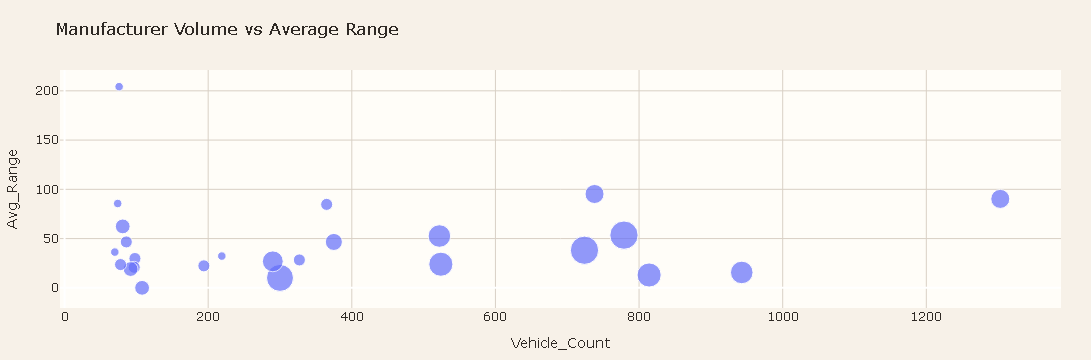

In [39]:
if PLOTLY_AVAILABLE:
    plot_data = portfolio_matrix.head(25)

    fig = px.scatter(
        plot_data,
        x="Vehicle_Count",
        y="Avg_Range",
        size="Model_Count",
        hover_name="Make",
        hover_data=[
            "Avg_MSRP",
            "Avg_Vehicle_Age"
        ],
        title="Manufacturer Volume vs Average Range"
    )

    fig = apply_theme(fig)
    fig.show()

## 39. Heatmap — State × EV Type

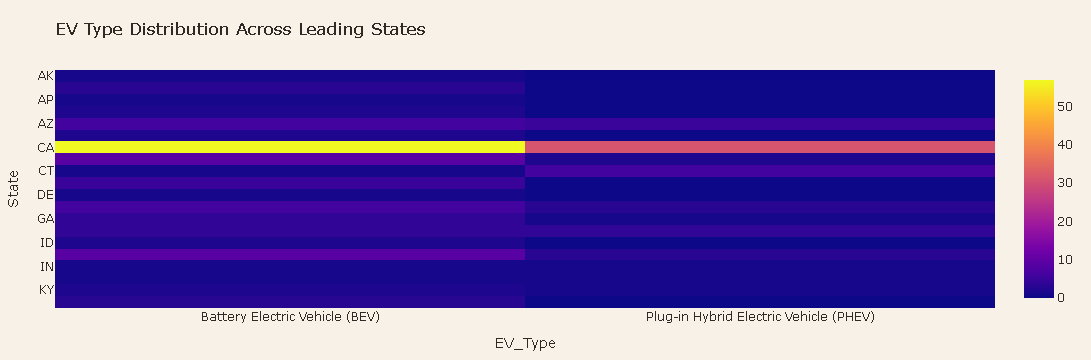

In [40]:
if PLOTLY_AVAILABLE:
    heatmap_data = state_evtype.head(20)

    fig = px.imshow(
        heatmap_data,
        aspect="auto",
        title="EV Type Distribution Across Leading States"
    )

    fig = apply_theme(fig)
    fig.show()

# 🎛️ Interactive Dashboard Filter Logic

## 40. Reusable Dashboard Filter Function

In [41]:
def filter_dashboard(
    data,
    years=None,
    makes=None,
    models=None,
    states=None,
    counties=None,
    cities=None,
    ev_types=None,
    cafv=None,
    age_groups=None,
    range_groups=None,
    msrp_groups=None
):
    result = data.copy()

    filters = {
        "Model_Year": years,
        "Make": makes,
        "Model": models,
        "State": states,
        "County": counties,
        "City": cities,
        "EV_Type": ev_types,
        "CAFV_Eligibility": cafv,
        "Age_Group": age_groups,
        "Range_Group": range_groups,
        "MSRP_Group": msrp_groups
    }

    for column, values in filters.items():
        if values:
            result = result[result[column].isin(values)]

    return result


print("✅ Dashboard filter engine ready")

✅ Dashboard filter engine ready


## 41. Example Slicer Selection

In [42]:
filtered_df = filter_dashboard(
    df,
    years=[2022, 2023, 2024],
    ev_types=None
)

print("Original rows :", len(df))
print("Filtered rows :", len(filtered_df))

display(filtered_df.head())

Original rows : 150482
Filtered rows : 65520


,VIN,County,City,State,Postal_Code,Model_Year,Make,Model,EV_Type,CAFV_Eligibility,...,Vehicle_ID,Vehicle_Location,Electric_Utility,Census_Tract,Legislative_District,Vehicle_Count,Vehicle_Age,Age_Group,Range_Group,MSRP_Group
1,1C4RJYB61N,King,Bothell,WA,98011.0,2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,233928502,POINT (-122.20578 47.762405),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033021804.0,1,1,2,0–3 Years,0–50,< $30K
2,1C4RJYD61P,Yakima,Yakima,WA,98908.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,229675939,POINT (-120.6027202 46.5965625),PACIFICORP,53077002900.0,14,1,1,0–3 Years,0–50,< $30K
9,7SAYGDEF0P,King,Bellevue,WA,98004.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,...,240416207,POINT (-122.201905 47.61385),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033023806.0,48,1,1,0–3 Years,0–50,< $30K
34,5YJ3E1EA4P,King,Bellevue,WA,98006.0,2023,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,...,241481278,POINT (-122.16937 47.571015),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033024704.0,41,1,1,0–3 Years,0–50,< $30K
38,1V2DNPE83P,King,Seattle,WA,98125.0,2023,VOLKSWAGEN,ID.4,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,...,245619664,POINT (-122.296385 47.71558),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033000900.0,46,1,1,0–3 Years,0–50,< $30K


## 42. Dynamic KPI Calculation

In [43]:
def dashboard_kpis(data):
    return pd.Series({
        "Total Vehicles": data["VIN"].nunique(),
        "Manufacturers": data["Make"].nunique(),
        "Models": data["Model"].nunique(),
        "States": data["State"].nunique(),
        "Average Range": data["Electric_Range"].mean(),
        "Median Range": data["Electric_Range"].median(),
        "Average MSRP": data["Base_MSRP"].mean(),
        "Average Age": data["Vehicle_Age"].mean()
    })


display(dashboard_kpis(filtered_df))

Total Vehicles    3951.000000
Manufacturers       30.000000
Models              82.000000
States              27.000000
Average Range        4.604991
Median Range         0.000000
Average MSRP         0.000000
Average Age          1.414484
dtype: float64

## 43. Dynamic Top Manufacturers

In [44]:
def top_manufacturers(data, n=10):
    return (
        data.groupby("Make")["VIN"]
        .nunique()
        .sort_values(ascending=False)
        .head(n)
        .reset_index(name="Vehicle_Count")
    )


display(top_manufacturers(filtered_df, 10))

,Make,Vehicle_Count
0,VOLVO,513
1,AUDI,447
2,FORD,385
3,HYUNDAI,277
4,TESLA,264
5,KIA,238
6,BMW,206
7,MERCEDES-BENZ,182
8,JEEP,172
9,PORSCHE,163


# 💡 Executive Business Insights

## 44. Market Concentration

In [45]:
top5_make_share = (
    manufacturer_summary.head(5)["Vehicle_Count"].sum()
    / manufacturer_summary["Vehicle_Count"].sum()
    * 100
)

top5_state_share = (
    state_summary.head(5)["Vehicle_Count"].sum()
    / state_summary["Vehicle_Count"].sum()
    * 100
)

print(f"Top 5 manufacturers share: {top5_make_share:.2f}%")
print(f"Top 5 states share: {top5_state_share:.2f}%")

Top 5 manufacturers share: 48.03%
Top 5 states share: 98.38%


## 45. Leading Market Indicators

In [46]:
leading_make = manufacturer_summary.iloc[0]
leading_state = state_summary.iloc[0]
leading_ev_type = ev_type_summary.iloc[0]

print("LEADING MARKET INDICATORS")
print("=" * 60)
print(
    f"Leading manufacturer : "
    f"{leading_make['Make']} "
    f"({leading_make['Vehicle_Count']:,} vehicles)"
)
print(
    f"Leading state        : "
    f"{leading_state['State']} "
    f"({leading_state['Vehicle_Count']:,} vehicles)"
)
print(
    f"Leading EV type      : "
    f"{leading_ev_type['EV_Type']} "
    f"({leading_ev_type['Vehicle_Count']:,} vehicles)"
)

LEADING MARKET INDICATORS
Leading manufacturer : TESLA (1,303 vehicles)
Leading state        : WA (9,522 vehicles)
Leading EV type      : Battery Electric Vehicle (BEV) (5,341 vehicles)


## 46. Range & Pricing Insight

In [47]:
range_stats = df[
    df["Electric_Range"] > 0
][["Electric_Range", "Base_MSRP"]].describe()

print("Electric Range statistics:")
display(range_stats)

Electric Range statistics:


,Electric_Range,Base_MSRP
count,80784.000000,80784.000000
mean,126.440793,2445.155043
std,99.221517,12488.856464
min,6.000000,0.000000
25%,32.000000,0.000000
50%,84.000000,0.000000
75%,215.000000,0.000000
max,337.000000,845000.000000


## 47. Age Profile Insight

In [48]:
age_profile = (
    df.groupby("Age_Group", observed=False)
      .agg(
          Vehicle_Count=("VIN", "nunique"),
          Avg_Range=("Electric_Range", "mean"),
          Avg_MSRP=("Base_MSRP", "mean")
      )
      .reset_index()
)

display(age_profile)

,Age_Group,Vehicle_Count,Avg_Range,Avg_MSRP
0,0–3 Years,5090,5.982471,0.000000
1,4–6 Years,2207,188.307500,1591.168797
2,7–10 Years,1723,101.489263,3100.124500
3,10+ Years,509,75.896244,9771.110560


# 📤 Power BI Export Layer

## 48. Prepare Power BI Fact Table

The fact table is generated directly from the cleaned dataset. This avoids dependency on a missing external file.

In [49]:
fact_columns = [
    "VIN",
    "County",
    "City",
    "State",
    "Postal_Code",
    "Model_Year",
    "Make",
    "Model",
    "EV_Type",
    "CAFV_Eligibility",
    "Electric_Range",
    "Base_MSRP",
    "Legislative_District",
    "Vehicle_ID",
    "Vehicle_Location",
    "Electric_Utility",
    "Census_Tract",
    "Vehicle_Count",
    "Vehicle_Age",
    "Age_Group",
    "Range_Group",
    "MSRP_Group"
]

fact_ev = df[fact_columns].copy()

print("Fact table shape:", fact_ev.shape)
display(fact_ev.head())

Fact table shape: (150482, 22)


,VIN,County,City,State,Postal_Code,Model_Year,Make,Model,EV_Type,CAFV_Eligibility,...,Legislative_District,Vehicle_ID,Vehicle_Location,Electric_Utility,Census_Tract,Vehicle_Count,Vehicle_Age,Age_Group,Range_Group,MSRP_Group
0,KM8K33AGXL,King,Seattle,WA,98103.0,2020,HYUNDAI,KONA,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,43,249675142,POINT (-122.34301 47.659185),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033004800.0,1,4,4–6 Years,201–300,< $30K
1,1C4RJYB61N,King,Bothell,WA,98011.0,2022,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,1,233928502,POINT (-122.20578 47.762405),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033021804.0,1,2,0–3 Years,0–50,< $30K
2,1C4RJYD61P,Yakima,Yakima,WA,98908.0,2023,JEEP,GRAND CHEROKEE,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,...,14,229675939,POINT (-120.6027202 46.5965625),PACIFICORP,53077002900.0,1,1,0–3 Years,0–50,< $30K
3,5YJ3E1EA7J,King,Kirkland,WA,98034.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,...,45,104714466,POINT (-122.209285 47.71124),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033021903.0,1,6,4–6 Years,201–300,< $30K
4,WBY7Z8C5XJ,Thurston,Olympia,WA,98501.0,2018,BMW,I3,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,...,22,185498386,POINT (-122.89692 47.043535),PUGET SOUND ENERGY INC,53067010700.0,1,6,4–6 Years,51–100,< $30K


## 49. Create Dimension Tables

In [50]:
dim_make = (
    df[["Make"]]
    .drop_duplicates()
    .sort_values("Make")
    .reset_index(drop=True)
)

dim_model = (
    df[["Make", "Model"]]
    .drop_duplicates()
    .sort_values(["Make", "Model"])
    .reset_index(drop=True)
)

dim_location = (
    df[[
        "State",
        "County",
        "City",
        "Postal_Code",
        "Vehicle_Location",
        "Census_Tract"
    ]]
    .drop_duplicates()
    .reset_index(drop=True)
)

dim_ev_type = (
    df[["EV_Type"]]
    .drop_duplicates()
    .sort_values("EV_Type")
    .reset_index(drop=True)
)

dim_cafv = (
    df[["CAFV_Eligibility"]]
    .drop_duplicates()
    .sort_values("CAFV_Eligibility")
    .reset_index(drop=True)
)

dim_utility = (
    df[["Electric_Utility"]]
    .drop_duplicates()
    .sort_values("Electric_Utility")
    .reset_index(drop=True)
)

dim_date = (
    df[["Model_Year"]]
    .drop_duplicates()
    .sort_values("Model_Year")
    .reset_index(drop=True)
)

print("Dimensions created:")
print("dim_make      :", dim_make.shape)
print("dim_model     :", dim_model.shape)
print("dim_location  :", dim_location.shape)
print("dim_ev_type   :", dim_ev_type.shape)
print("dim_cafv      :", dim_cafv.shape)
print("dim_utility   :", dim_utility.shape)
print("dim_date      :", dim_date.shape)

Dimensions created:
dim_make      : (37, 1)
dim_model     : (127, 2)
dim_location  : (5673, 6)
dim_ev_type   : (2, 1)
dim_cafv      : (3, 1)
dim_utility   : (76, 1)
dim_date      : (22, 1)


## 50. Export Power BI Tables

In [51]:
powerbi_exports = {
    "fact_ev.csv": fact_ev,
    "dim_make.csv": dim_make,
    "dim_model.csv": dim_model,
    "dim_location.csv": dim_location,
    "dim_ev_type.csv": dim_ev_type,
    "dim_cafv.csv": dim_cafv,
    "dim_utility.csv": dim_utility,
    "dim_date.csv": dim_date,
    "kpis.csv": kpis,
    "year_summary.csv": year_summary,
    "manufacturer_summary.csv": manufacturer_summary,
    "model_summary.csv": model_summary,
    "state_summary.csv": state_summary,
    "county_summary.csv": county_summary,
    "city_summary.csv": city_summary,
    "ev_type_summary.csv": ev_type_summary,
    "cafv_summary.csv": cafv_summary,
    "utility_summary.csv": utility_summary,
    "range_summary.csv": range_summary,
    "msrp_summary.csv": msrp_summary,
    "age_summary.csv": age_summary,
    "portfolio_matrix.csv": portfolio_matrix,
    "state_evtype.csv": state_evtype,
    "make_evtype.csv": make_evtype,
    "year_evtype.csv": year_evtype
}

for filename, table in powerbi_exports.items():
    table.to_csv(POWERBI_DIR / filename, index=False)

print(f"✅ {len(powerbi_exports)} Power BI files exported")
print("Location:", POWERBI_DIR.resolve())

✅ 25 Power BI files exported
Location: D:\ev_project_v2-Data Analysis\outputs\powerbi


# 📊 Dashboard Blueprint

## 51. Page 1 — Executive Overview

### KPI Cards

- Total Vehicles
- Manufacturers
- Models
- States
- Average Range
- Average MSRP

### Main visuals

- EV population by Model Year
- Top 10 Manufacturers
- EV Type Mix
- Top States

### Global slicers

- Model Year
- State
- Make
- EV Type


## 52. Page 2 — EV Market Intelligence

### Visuals

- Manufacturer ranking
- Model ranking
- Manufacturer market share
- Manufacturer portfolio matrix
- Year-wise vehicle population

### Slicers

- Model Year
- Make
- Model
- EV Type


## 53. Page 3 — Geographic Intelligence

### Visuals

- State ranking
- County ranking
- City ranking
- State × EV Type heatmap
- State × Manufacturer analysis

### Slicers

- State
- County
- City
- EV Type


## 54. Page 4 — EV Technology

### Visuals

- EV Type mix
- CAFV eligibility distribution
- Electric range distribution
- Range segments
- Year × EV Type trend

### Slicers

- EV Type
- CAFV Eligibility
- Model Year
- Range Group


## 55. Page 5 — Pricing & Vehicle Profile

### Visuals

- MSRP distribution
- Range vs MSRP
- Vehicle age distribution
- MSRP segments
- Manufacturer volume vs range

### Slicers

- Make
- Model
- MSRP Group
- Range Group
- Age Group


## 56. Page 6 — Advanced Insights

### Visuals

- Market concentration
- Portfolio matrix
- State × EV Type matrix
- Manufacturer × EV Type matrix
- Executive insight cards

### Slicers

Use all major dashboard filters.

# 🎨 Power BI UX / Design Specification

### Layout

```text
┌─────────────────────────────────────────────────────┐
│ EV INTELLIGENCE PLATFORM                            │
│ Dynamic filter summary                              │
├────────────┬────────────┬────────────┬──────────────┤
│ KPI        │ KPI        │ KPI        │ KPI          │
├────────────┴────────────┴────────────┴──────────────┤
│ Main Trend / Market Visual                          │
├─────────────────────────────┬───────────────────────┤
│ Manufacturer Analysis       │ EV Type Analysis      │
├─────────────────────────────┴───────────────────────┤
│ Geographic / Detail Table                           │
└─────────────────────────────────────────────────────┘
```

### UX principles

- Keep KPI cards aligned.
- Keep chart titles descriptive.
- Show units on axes.
- Avoid overcrowding.
- Keep slicers in one consistent area.
- Use drill-through for detailed manufacturer and location views.
- Use tooltips for supporting metrics.
- Add a Reset Filters button.
- Keep the visual hierarchy consistent across pages.


# ✅ Final Dashboard Quality Gate

In [52]:
dashboard_checks = {
    "Dataset loaded": len(df) > 0,
    "Required columns present": len(missing_columns) == 0,
    "KPI table created": len(kpis) > 0,
    "Year summary created": len(year_summary) > 0,
    "Manufacturer summary created": len(manufacturer_summary) > 0,
    "State summary created": len(state_summary) > 0,
    "EV type summary created": len(ev_type_summary) > 0,
    "Fact table created": len(fact_ev) > 0,
    "No negative electric range": (df["Electric_Range"] < 0).sum() == 0,
    "No negative MSRP": (df["Base_MSRP"] < 0).sum() == 0,
    "Dashboard output exists": DASH_DIR.exists(),
    "Power BI output exists": POWERBI_DIR.exists()
}

dashboard_quality = pd.DataFrame({
    "Check": dashboard_checks.keys(),
    "Passed": dashboard_checks.values()
})

display(dashboard_quality)

if dashboard_quality["Passed"].all():
    print("🏆 FINAL DASHBOARD QUALITY GATE PASSED")
else:
    print("⚠️ Review failed checks before publishing.")

,Check,Passed
0,Dataset loaded,True
1,Required columns present,True
2,KPI table created,True
3,Year summary created,True
4,Manufacturer summary created,True
5,State summary created,True
6,EV type summary created,True
7,Fact table created,True
8,No negative electric range,True
9,No negative MSRP,True


🏆 FINAL DASHBOARD QUALITY GATE PASSED


## Dashbord

# ⚡ EV Intelligence Dashboard

> Interactive Electric Vehicle Market Analytics Dashboard

An interactive **Electric Vehicle Intelligence Dashboard** designed to analyze EV market data using a Power BI-inspired web interface.

The dashboard provides interactive filtering, KPI analysis, data visualization, manufacturer performance analysis, and a searchable manufacturer summary table.

---

## 📊 Project Overview

The **EV Intelligence Dashboard** transforms cleaned Electric Vehicle registration data into an interactive Business Intelligence dashboard.

The project focuses on:

- Electric Vehicle market trends
- Manufacturer performance
- EV technology distribution
- State-wise EV adoption
- Electric vehicle range analysis
- MSRP analysis
- CAFV eligibility
- Electric utility analysis
- City-level EV distribution
- Manufacturer portfolio performance

---

## 🎯 Project Objectives

The main objectives of this project are:

1. Analyze the EV market using cleaned vehicle registration data.
2. Identify leading EV manufacturers.
3. Understand EV technology adoption.
4. Analyze electric range across vehicles.
5. Study EV distribution across states and cities.
6. Analyze manufacturer volume and portfolio performance.
7. Compare average range and MSRP.
8. Analyze CAFV eligibility.
9. Identify major electric utilities associated with EV registrations.
10. Provide an interactive BI-style dashboard for decision support.

---

# 🗂️ Project Structure

```text
EV-Intelligence-Dashboard/
│
├── dashboard/
│   └── index.html
    └── app.py
├── datas/
│   └── cleaned/
│       └── ev_cleaned.csv
│
├── README.md
│
└── requirements.txt

In [1]:

# ============================================================
# EV INTELLIGENCE DASHBOARD
# PROFESSIONAL STABLE SINGLE-FILE PLOTLY DASH APPLICATION
# ============================================================
#
# FIXED:
# - KPIs now populate correctly
# - All 12 charts are connected to the dashboard callback
# - Theme actually changes chart + page colors
# - Filters update KPIs, charts and summary table
# - Reset button works
# - Summary table sorting/filtering/pagination works
# - Download CSV button exports current table view
# - Fixed port 8050, no input prompt
# - Reference Year = 2024
# - No __file__ usage
# ============================================================

from pathlib import Path
import textwrap
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from dash import Dash, dcc, html, dash_table, Input, Output, State, ctx
from dash.exceptions import PreventUpdate

import plotly.express as px
import plotly.graph_objects as go


# ============================================================
# 1. PROJECT + DATA
# ============================================================

PROJECT_ROOT = Path(r"D:\ev_project_v2-Data Analysis")
CLEANED_FILE = PROJECT_ROOT / "datas" / "cleaned" / "ev_cleaned.csv"

REFERENCE_YEAR = 2024

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f"Project root not found:\n{PROJECT_ROOT}"
    )

if not CLEANED_FILE.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found:\n{CLEANED_FILE}\n"
    )

df = pd.read_csv(CLEANED_FILE)


# ============================================================
# 2. VALIDATION + CLEANING
# ============================================================

REQUIRED_COLUMNS = [
    "VIN",
    "County",
    "City",
    "State",
    "Postal_Code",
    "Model_Year",
    "Make",
    "Model",
    "EV_Type",
    "CAFV_Eligibility",
    "Electric_Range",
    "Base_MSRP",
    "Vehicle_ID",
    "Vehicle_Location",
    "Electric_Utility",
    "Census_Tract",
    "Legislative_District",
]

missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
if missing:
    raise KeyError(
        f"Missing required columns: {missing}\n"
        f"Available columns: {df.columns.tolist()}"
    )

for col in [
    "Model_Year",
    "Electric_Range",
    "Base_MSRP",
    "Legislative_District",
]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

for col in [
    "VIN",
    "County",
    "City",
    "State",
    "Postal_Code",
    "Make",
    "Model",
    "EV_Type",
    "CAFV_Eligibility",
    "Vehicle_ID",
    "Vehicle_Location",
    "Electric_Utility",
    "Census_Tract",
]:
    df[col] = (
        df[col]
        .astype("string")
        .fillna("Unknown")
        .str.strip()
        .replace("", "Unknown")
    )

df["Vehicle_Count"] = 1
df["Vehicle_Age"] = (REFERENCE_YEAR - df["Model_Year"]).clip(lower=0)

# Keep unknown values out of the band cuts by using NaN first.
df["Range_Band"] = pd.cut(
    df["Electric_Range"],
    bins=[-np.inf, 50, 100, 150, 200, 250, 300, np.inf],
    labels=[
        "<= 50",
        "51–100",
        "101–150",
        "151–200",
        "201–250",
        "251–300",
        "> 300",
    ],
    include_lowest=True,
)

df["MSRP_Band"] = pd.cut(
    df["Base_MSRP"],
    bins=[-np.inf, 25000, 40000, 60000, 80000, 120000, np.inf],
    labels=[
        "<= $25K",
        "$25K–$40K",
        "$40K–$60K",
        "$60K–$80K",
        "$80K–$120K",
        "> $120K",
    ],
    include_lowest=True,
)


# ============================================================
# 3. THEMES
# ============================================================

THEMES = {
    "green": {
        "name": "Green",
        "page": "#F3FAF4",
        "surface": "#FFFFFF",
        "surface2": "#F8FCF8",
        "text": "#18352A",
        "muted": "#64756D",
        "border": "#D8E8DC",
        "primary": "#208A5A",
        "primary2": "#45B97C",
        "accent": "#A7DDBB",
        "accent2": "#75C993",
        "grid": "#DDEBE1",
        "palette": [
            "#166534", "#208A5A", "#45B97C",
            "#75C993", "#A7DDBB", "#D8F0DF",
        ],
        "sequential": "Greens",
    },
    "cream": {
        "name": "Cream",
        "page": "#FFF8E7",
        "surface": "#FFFFFF",
        "surface2": "#FFFDF7",
        "text": "#27343F",
        "muted": "#687684",
        "border": "#E8DDC7",
        "primary": "#287D5A",
        "primary2": "#69A77F",
        "accent": "#DDBF8C",
        "accent2": "#B98A4A",
        "grid": "#EEE6D7",
        "palette": [
            "#287D5A", "#4E966F", "#78B890",
            "#A6CDAF", "#DDBF8C", "#B98A4A",
        ],
        "sequential": "YlGn",
    },
    "chocolate": {
        "name": "Chocolate",
        "page": "#FBF5EF",
        "surface": "#FFFFFF",
        "surface2": "#FFF9F3",
        "text": "#3D281C",
        "muted": "#806957",
        "border": "#E8D8C9",
        "primary": "#7B4B2A",
        "primary2": "#A86F45",
        "accent": "#D8B08A",
        "accent2": "#B9835A",
        "grid": "#EBDDD0",
        "palette": [
            "#5A321D", "#7B4B2A", "#A86F45",
            "#C3926C", "#D8B08A", "#EBD7C4",
        ],
        "sequential": "YlOrBr",
    },
    "dark": {
        "name": "Dark",
        "page": "#101815",
        "surface": "#18221E",
        "surface2": "#1E2B25",
        "text": "#EAF5EE",
        "muted": "#A7B9AF",
        "border": "#31463C",
        "primary": "#52C788",
        "primary2": "#7BE0A6",
        "accent": "#214B36",
        "accent2": "#3D9667",
        "grid": "#30453B",
        "palette": [
            "#52C788", "#7BE0A6", "#3D9667",
            "#2B704C", "#9BE7BA", "#C5F3D5",
        ],
        "sequential": "Greens",
    },
    "white": {
        "name": "White",
        "page": "#FFFFFF",
        "surface": "#FFFFFF",
        "surface2": "#FAFAFA",
        "text": "#202B33",
        "muted": "#68737C",
        "border": "#DCE2E6",
        "primary": "#16825A",
        "primary2": "#43A879",
        "accent": "#CFE9DB",
        "accent2": "#79C49D",
        "grid": "#E5EAED",
        "palette": [
            "#16825A", "#43A879", "#79C49D",
            "#A5D5B9", "#CFE9DB", "#E6F3EB",
        ],
        "sequential": "Greens",
    },
}

THEME_ORDER = ["green", "cream", "chocolate", "dark", "white"]


# ============================================================
# 4. OPTIONS + FILTER ENGINE
# ============================================================

def make_options(series, numeric=False):
    values = series.dropna().unique().tolist()
    if numeric:
        values = sorted(values)
        return [{"label": str(int(v)), "value": int(v)} for v in values]
    values = sorted([str(v) for v in values])
    return [{"label": v, "value": v} for v in values]


YEAR_OPTIONS = make_options(df["Model_Year"], numeric=True)
STATE_OPTIONS = make_options(df["State"])
MAKE_OPTIONS = make_options(df["Make"])
EV_TYPE_OPTIONS = make_options(df["EV_Type"])
CAFV_OPTIONS = make_options(df["CAFV_Eligibility"])
UTILITY_OPTIONS = make_options(df["Electric_Utility"])


def apply_filters(
    data,
    years=None,
    states=None,
    makes=None,
    ev_types=None,
    cafv=None,
    utilities=None,
):
    result = data

    if years:
        result = result[result["Model_Year"].isin(years)]
    if states:
        result = result[result["State"].isin(states)]
    if makes:
        result = result[result["Make"].isin(makes)]
    if ev_types:
        result = result[result["EV_Type"].isin(ev_types)]
    if cafv:
        result = result[result["CAFV_Eligibility"].isin(cafv)]
    if utilities:
        result = result[result["Electric_Utility"].isin(utilities)]

    return result


# ============================================================
# 5. FORMAT HELPERS
# ============================================================

def fmt_int(value):
    return "N/A" if pd.isna(value) else f"{float(value):,.0f}"


def fmt_one(value):
    return "N/A" if pd.isna(value) else f"{float(value):,.1f}"


def fmt_money(value):
    return "N/A" if pd.isna(value) else f"${float(value):,.0f}"


def fmt_pct(value):
    return "N/A" if pd.isna(value) else f"{float(value):.1f}%"


# ============================================================
# 6. PLOT HELPERS
# ============================================================
#
# Premium chart treatment:
# - Gridlines removed.
# - Camera / export / zoom / home-style Plotly controls removed.
# - Remaining toolbar is positioned under the chart title.
# - Chart heights, widths, layout and data calculations remain unchanged.
#

def apply_plot_theme(fig, theme_name, height=560, margin=None):
    t = THEMES[theme_name]

    if margin is None:
        margin = dict(l=75, r=60, t=105, b=75)

    fig.update_layout(
        template="plotly_dark" if theme_name == "dark" else "plotly_white",
        paper_bgcolor=t["surface"],
        plot_bgcolor=t["surface"],
        height=height,
        margin=margin,
        font=dict(
            family="Arial, Helvetica, sans-serif",
            color=t["text"],
            size=12,
        ),
        title=dict(
            font=dict(size=19, color=t["text"]),
            x=0.02,
            xanchor="left",
            y=0.98,
            yanchor="top",
        ),
        hoverlabel=dict(
            bgcolor=t["surface"],
            font_color=t["text"],
            font_size=13,
        ),
        legend=dict(
            font=dict(color=t["text"]),
        ),
    )

    # Premium clean-chart treatment: no gridlines / zero-lines.
    # Size, margins, widths and dashboard layout are unchanged.
    fig.update_xaxes(
        showgrid=False,
        zeroline=False,
        linecolor=t["border"],
        tickfont=dict(color=t["muted"]),
        title_font=dict(color=t["text"]),
        automargin=True,
    )

    fig.update_yaxes(
        showgrid=False,
        zeroline=False,
        linecolor=t["border"],
        tickfont=dict(color=t["muted"]),
        title_font=dict(color=t["text"]),
        automargin=True,
    )

    return fig


def make_bar(fig, theme, height=560, left=100, right=80):
    return apply_plot_theme(
        fig,
        theme,
        height=height,
        margin=dict(l=left, r=right, t=105, b=75),
    )


def empty_figure(theme, title="No data available"):
    fig = go.Figure()
    fig.add_annotation(
        text="No records match the selected filters",
        x=0.5, y=0.5,
        xref="paper", yref="paper",
        showarrow=False,
        font=dict(size=18, color=THEMES[theme]["muted"]),
    )
    fig.update_layout(title=title)
    return apply_plot_theme(fig, theme, height=560)


def wrap_utility_label(value, width=30):
    value = str(value).strip()
    if not value:
        return "Unknown"
    parts = textwrap.wrap(
        value,
        width=width,
        break_long_words=False,
        break_on_hyphens=False,
    )
    return "<br>".join(parts[:3])


# ============================================================
# 7. UI HELPERS
# ============================================================

def kpi_card(title, component_id, icon):
    return html.Div(
        [
            html.Div(
                [
                    html.Span(icon, className="kpi-icon"),
                    html.Span(title),
                ],
                className="kpi-label",
            ),
            html.Div("--", id=component_id, className="kpi-value"),
        ],
        className="kpi-card",
    )


def filter_dropdown(label, component_id, options):
    return html.Div(
        [
            html.Label(label, className="filter-label"),
            dcc.Dropdown(
                id=component_id,
                options=options,
                value=None,
                multi=True,
                clearable=True,
                searchable=True,
                placeholder=f"Select {label}",
                className="dash-filter",
            ),
        ],
        className="filter-item",
    )


def chart_card(component_id):
    return html.Div(
        dcc.Graph(
            id=component_id,
            config={
                "displaylogo": False,
                "displayModeBar": True,
                "responsive": True,
                "modeBarButtonsToRemove": [
                    "toImage",
                    "sendDataToCloud",
                    "zoom2d",
                    "pan2d",
                    "select2d",
                    "lasso2d",
                    "zoomIn2d",
                    "zoomOut2d",
                    "autoScale2d",
                    "resetScale2d",
                    "hoverClosestCartesian",
                    "hoverCompareCartesian",
                    "toggleSpikelines",
                ],
            },
            style={"width": "100%"},
        ),
        className="chart-card",
    )


# ============================================================
# 8. DASH APP
# ============================================================

app = Dash(
    __name__,
    title="EV Intelligence Dashboard",
    suppress_callback_exceptions=True,
)

server = app.server


# ============================================================
# 9. CSS
# ============================================================

app.index_string = r"""
<!DOCTYPE html>
<html>
<head>
{%metas%}
<title>{%title%}</title>
{%favicon%}
{%css%}

<style>

* { box-sizing: border-box; }

html, body {
    margin: 0;
    padding: 0;
    width: 100%;
    min-height: 100%;
    font-family: Arial, Helvetica, sans-serif;
}

body {
    background: var(--page);
}

.app-shell {
    min-height: 100vh;
    background: var(--page);
    color: var(--text);
    --page: #F3FAF4;
    --surface: #FFFFFF;
    --surface2: #F8FCF8;
    --text: #18352A;
    --muted: #64756D;
    --border: #D8E8DC;
    --primary: #208A5A;
    --primary2: #45B97C;
    --accent: #A7DDBB;
    --accent2: #75C993;
}

.dashboard-container {
    width: 100%;
    max-width: 1900px;
    margin: 0 auto;
    padding: 20px;
}

.hero {
    background: var(--surface);
    border: 1px solid var(--border);
    border-radius: 22px;
    padding: 24px 28px;
    margin-bottom: 18px;
    box-shadow: 0 7px 24px rgba(0,0,0,.055);
}

.hero-layout {
    display: flex;
    align-items: center;
    justify-content: space-between;
    gap: 24px;
}

.hero-left {
    display: flex;
    align-items: center;
    gap: 18px;
    min-width: 0;
}

.logo {
    width: 58px;
    height: 58px;
    min-width: 58px;
    border-radius: 18px;
    display: grid;
    place-items: center;
    background: var(--primary);
    color: #FFFFFF;
    font-weight: 900;
    font-size: 20px;
}

.hero-title {
    margin: 0;
    color: var(--text);
    font-size: clamp(30px, 3vw, 44px);
    line-height: 1.05;
    font-weight: 900;
}

.hero-subtitle {
    margin: 8px 0 0;
    color: var(--muted);
    font-size: 15px;
    line-height: 1.45;
}

.hero-right {
    display: flex;
    align-items: center;
    justify-content: flex-end;
    gap: 16px;
    flex-wrap: wrap;
}

.reference-box {
    min-width: 135px;
    text-align: center;
    padding: 11px 18px;
    border: 1px solid var(--border);
    border-radius: 16px;
    background: var(--surface2);
}

.reference-label, .theme-label {
    color: var(--muted);
    font-size: 11px;
    font-weight: 700;
    letter-spacing: .4px;
    text-transform: uppercase;
}

.reference-year {
    color: var(--text);
    font-size: 27px;
    line-height: 1.05;
    font-weight: 900;
    margin-top: 3px;
}

.theme-box {
    display: flex;
    flex-direction: column;
    gap: 6px;
}

.theme-cycle {
    border: 1px solid var(--border);
    background: var(--surface);
    color: var(--text);
    border-radius: 12px;
    padding: 10px 16px;
    font-size: 13px;
    font-weight: 800;
    cursor: pointer;
}

.filter-card, .table-card {
    background: var(--surface);
    border: 1px solid var(--border);
    border-radius: 20px;
    padding: 24px 28px;
    margin-bottom: 18px;
    box-shadow: 0 7px 24px rgba(0,0,0,.05);
}

.section-head {
    display: flex;
    align-items: flex-start;
    justify-content: space-between;
    gap: 18px;
    margin-bottom: 20px;
}

.section-title {
    margin: 0;
    color: var(--text);
    font-size: 23px;
    line-height: 1.2;
    font-weight: 850;
}

.section-description {
    margin: 7px 0 0;
    color: var(--muted);
    font-size: 13px;
}

.reset-button, .download-button {
    border: 0;
    background: var(--primary);
    color: #FFFFFF;
    border-radius: 12px;
    padding: 12px 19px;
    font-size: 13px;
    font-weight: 800;
    cursor: pointer;
}

.filter-grid {
    display: grid;
    grid-template-columns: repeat(3, minmax(0, 1fr));
    gap: 17px 18px;
}

.filter-item { min-width: 0; }

.filter-label {
    display: block;
    color: var(--text);
    font-size: 13px;
    font-weight: 800;
    margin-bottom: 7px;
}

.dash-filter .Select-control {
    min-height: 45px;
    border-radius: 9px !important;
    border-color: var(--border) !important;
    background: var(--surface) !important;
}

.dash-filter .Select-menu-outer {
    background: var(--surface) !important;
    color: var(--text) !important;
    border-color: var(--border) !important;
    z-index: 3000 !important;
}

.dash-filter .Select-placeholder,
.dash-filter .Select-value-label {
    color: var(--muted) !important;
}

.dash-filter .Select-option {
    background: var(--surface) !important;
    color: var(--text) !important;
}

.kpi-grid {
    display: grid;
    grid-template-columns: repeat(5, minmax(0, 1fr));
    gap: 14px;
    margin-bottom: 18px;
}

.kpi-card {
    min-width: 0;
    min-height: 112px;
    background: var(--surface);
    border: 1px solid var(--border);
    border-radius: 16px;
    padding: 15px;
    box-shadow: 0 5px 18px rgba(0,0,0,.045);
    display: flex;
    flex-direction: column;
    justify-content: center;
}

.kpi-label {
    display: flex;
    align-items: center;
    gap: 8px;
    color: var(--muted);
    font-size: 12px;
    font-weight: 800;
    line-height: 1.25;
}

.kpi-icon {
    width: 35px;
    height: 35px;
    min-width: 35px;
    display: grid;
    place-items: center;
    border-radius: 10px;
    background: var(--accent);
    color: var(--primary);
}

.kpi-value {
    margin-top: 7px;
    color: var(--text);
    font-size: 22px;
    line-height: 1.1;
    font-weight: 900;
    word-break: break-word;
}

.chart-grid-3 {
    display: grid;
    grid-template-columns: repeat(3, minmax(0, 1fr));
    gap: 18px;
    margin-bottom: 18px;
}

.chart-grid-2 {
    display: grid;
    grid-template-columns: repeat(2, minmax(0, 1fr));
    gap: 18px;
    margin-bottom: 18px;
}

.chart-card {
    min-width: 0;
    min-height: 560px;
    overflow: hidden;
    background: var(--surface);
    border: 1px solid var(--border);
    border-radius: 17px;
    padding: 6px;
    box-shadow: 0 5px 18px rgba(0,0,0,.045);
}

/* Plotly toolbar sits at the top of each chart, below the title. */
.chart-card .modebar-container {
    top: 42px !important;
    right: 8px !important;
}

.chart-card .modebar {
    margin-top: 0 !important;
}

.table-toolbar {
    display: flex;
    align-items: center;
    justify-content: space-between;
    gap: 14px;
    flex-wrap: wrap;
    margin: 4px 0 16px;
}

.table-hint {
    color: var(--muted);
    font-size: 12.5px;
}

.dash-spreadsheet-container .dash-spreadsheet-inner td {
    background: var(--surface) !important;
    color: var(--text) !important;
    border-color: var(--border) !important;
}

.dash-spreadsheet-container .dash-spreadsheet-inner th {
    background: var(--primary) !important;
    color: #FFFFFF !important;
}

.dash-spreadsheet-container input {
    color: var(--text) !important;
    background: var(--surface2) !important;
    border: 1px solid var(--border) !important;
}

.footer {
    text-align: center;
    color: var(--muted);
    padding: 22px 10px 8px;
    font-size: 12px;
    line-height: 1.5;
}

@media (max-width: 1450px) {
    .kpi-grid { grid-template-columns: repeat(4, minmax(0,1fr)); }
}

@media (max-width: 1100px) {
    .kpi-grid { grid-template-columns: repeat(3, minmax(0,1fr)); }
}

@media (max-width: 900px) {
    .hero-layout { flex-direction: column; align-items: flex-start; }
    .filter-grid { grid-template-columns: repeat(2, minmax(0,1fr)); }
    .chart-grid-3 { grid-template-columns: repeat(2, minmax(0,1fr)); }
    .chart-grid-2 { grid-template-columns: 1fr; }
}

@media (max-width: 650px) {
    .dashboard-container { padding: 10px; }
    .filter-grid, .kpi-grid, .chart-grid-3, .chart-grid-2 {
        grid-template-columns: 1fr;
    }
    .hero, .filter-card, .table-card { padding: 16px; }
}

</style>
</head>

<body>
{%app_entry%}
<footer>
{%config%}
{%scripts%}
{%renderer%}
</footer>
</body>
</html>
"""


# ============================================================
# 8. SUMMARY TABLE CONDITIONAL FORMATTING
# ============================================================
#
# FIX:
# DataTable is constructed while the module is loading, before
# update_dashboard() is ever executed. Therefore the conditional
# formatting rules must be defined at module scope.
# ============================================================

table_style_conditions = [

    # ----------------------------------------------------
    # MARKET SHARE — VERY HIGH
    # ----------------------------------------------------

    {
        "if": {
            "column_id": "Market Share %",
            "filter_query": (
                "{Market Share %} >= 10"
            ),
        },
        "backgroundColor": "#166534",
        "color": "#FFFFFF",
        "fontWeight": "800",
    },

    # ----------------------------------------------------
    # MARKET SHARE — HIGH
    # ----------------------------------------------------

    {
        "if": {
            "column_id": "Market Share %",
            "filter_query": (
                "{Market Share %} >= 5 && "
                "{Market Share %} < 10"
            ),
        },
        "backgroundColor": "#45B97C",
        "color": "#FFFFFF",
        "fontWeight": "800",
    },

    # ----------------------------------------------------
    # MARKET SHARE — MEDIUM
    # ----------------------------------------------------

    {
        "if": {
            "column_id": "Market Share %",
            "filter_query": (
                "{Market Share %} >= 2 && "
                "{Market Share %} < 5"
            ),
        },
        "backgroundColor": "#A7DDBB",
        "color": "#18352A",
        "fontWeight": "800",
    },

    # ----------------------------------------------------
    # MARKET SHARE BAR
    # ----------------------------------------------------

    {
        "if": {
            "column_id": "Market Share Bar",
        },
        "fontFamily": "Consolas, 'Courier New', monospace",
        "fontWeight": "800",
        "fontSize": "12px",
        "textAlign": "left",
        "letterSpacing": "0px",
    },

    # ----------------------------------------------------
    # VEHICLE RECORDS
    # ----------------------------------------------------

    {
        "if": {
            "column_id": "Vehicle Records",
            "filter_query": (
                "{Vehicle Records} >= 10000"
            ),
        },
        "fontWeight": "900",
        "color": "var(--primary)",
    },

    # ----------------------------------------------------
    # AVERAGE RANGE — STRONG
    # ----------------------------------------------------

    {
        "if": {
            "column_id": "Avg Range",
            "filter_query": (
                "{Avg Range} >= 250"
            ),
        },
        "backgroundColor": "#D8F0DF",
        "color": "#166534",
        "fontWeight": "800",
    },

    # ----------------------------------------------------
    # AVERAGE RANGE — MEDIUM
    # ----------------------------------------------------

    {
        "if": {
            "column_id": "Avg Range",
            "filter_query": (
                "{Avg Range} >= 150 && "
                "{Avg Range} < 250"
            ),
        },
        "backgroundColor": "#EDF7EF",
        "color": "#208A5A",
        "fontWeight": "700",
    },

    # ----------------------------------------------------
    # AVERAGE MSRP — HIGH
    # ----------------------------------------------------

    {
        "if": {
            "column_id": "Avg MSRP",
            "filter_query": (
                "{Avg MSRP} >= 75000"
            ),
        },
        "backgroundColor": "#FFF0E2",
        "color": "#7B4B2A",
        "fontWeight": "800",
    },

    # ----------------------------------------------------
    # RANGE VS OVERALL — ABOVE BENCHMARK
    # ----------------------------------------------------

    {
        "if": {
            "column_id": "Range vs Overall %",
            "filter_query": (
                "{Range vs Overall %} >= 110"
            ),
        },
        "backgroundColor": "#D8F0DF",
        "color": "#166534",
        "fontWeight": "800",
    },

    # ----------------------------------------------------
    # RANGE VS OVERALL — BELOW BENCHMARK
    # ----------------------------------------------------

    {
        "if": {
            "column_id": "Range vs Overall %",
            "filter_query": (
                "{Range vs Overall %} < 90"
            ),
        },
        "backgroundColor": "#FCE8E6",
        "color": "#9B2C2C",
        "fontWeight": "700",
    },

    # ----------------------------------------------------
    # PRICE VS OVERALL — ABOVE BENCHMARK
    # ----------------------------------------------------

    {
        "if": {
            "column_id": "Price vs Overall %",
            "filter_query": (
                "{Price vs Overall %} >= 120"
            ),
        },
        "backgroundColor": "#FFF0E2",
        "color": "#7B4B2A",
        "fontWeight": "800",
    },

    # ----------------------------------------------------
    # PRICE VS OVERALL — BELOW BENCHMARK
    # ----------------------------------------------------

    {
        "if": {
            "column_id": "Price vs Overall %",
            "filter_query": (
                "{Price vs Overall %} < 80"
            ),
        },
        "backgroundColor": "#EDF7EF",
        "color": "#166534",
        "fontWeight": "700",
    },

    # ----------------------------------------------------
    # VOLUME RANK — #1
    # ----------------------------------------------------

    {
        "if": {
            "filter_query": "{Volume Rank} = 1",
            "column_id": "Volume Rank",
        },
        "backgroundColor": "#F5D76E",
        "color": "#4D3F2F",
        "fontWeight": "900",
        "fontSize": "15px",
    },

    # ----------------------------------------------------
    # VOLUME RANK — #2
    # ----------------------------------------------------

    {
        "if": {
            "filter_query": "{Volume Rank} = 2",
            "column_id": "Volume Rank",
        },
        "backgroundColor": "#D9DEE5",
        "color": "#3E4650",
        "fontWeight": "900",
        "fontSize": "15px",
    },

    # ----------------------------------------------------
    # VOLUME RANK — #3
    # ----------------------------------------------------

    {
        "if": {
            "filter_query": "{Volume Rank} = 3",
            "column_id": "Volume Rank",
        },
        "backgroundColor": "#E6B98A",
        "color": "#5A321D",
        "fontWeight": "900",
        "fontSize": "15px",
    },
]

# ============================================================
# 10. LAYOUT
# ============================================================

app.layout = html.Div(
    id="app-shell",
    className="app-shell",
    children=[
        dcc.Store(
            id="theme-store",
            storage_type="local",
            data="green",
        ),
        dcc.Download(id="download-table-csv"),

        html.Div(
            className="dashboard-container",
            children=[

                # ---------------- HEADER ----------------
                html.Div(
                    className="hero",
                    children=[
                        html.Div(
                            className="hero-layout",
                            children=[
                                html.Div(
                                    className="hero-left",
                                    children=[
                                        html.Div("EV", className="logo"),
                                        html.Div(
                                            [
                                                html.H1(
                                                    "EV Intelligence Dashboard",
                                                    className="hero-title",
                                                ),
                                                html.P(
                                                    "Electric Vehicle Market Analytics • "
                                                    "Business Intelligence • "
                                                    "Interactive Decision Support",
                                                    className="hero-subtitle",
                                                ),
                                            ]
                                        ),
                                    ],
                                ),
                                html.Div(
                                    className="hero-right",
                                    children=[
                                        html.Div(
                                            [
                                                html.Div(
                                                    "Reference Year",
                                                    className="reference-label",
                                                ),
                                                html.Div(
                                                    str(REFERENCE_YEAR),
                                                    className="reference-year",
                                                ),
                                            ],
                                            className="reference-box",
                                        ),
                                        html.Div(
                                            [
                                                html.Div(
                                                    "Theme",
                                                    className="theme-label",
                                                ),
                                                html.Button(
                                                    "🌿 Green • Click to change",
                                                    id="theme-cycle",
                                                    n_clicks=0,
                                                    className="theme-cycle",
                                                ),
                                            ],
                                            className="theme-box",
                                        ),
                                    ],
                                ),
                            ]
                        )
                    ],
                ),

                # ---------------- FILTERS ----------------
                html.Div(
                    className="filter-card",
                    children=[
                        html.Div(
                            className="section-head",
                            children=[
                                html.Div(
                                    [
                                        html.H2(
                                            "Interactive Filters",
                                            className="section-title",
                                        ),
                                        html.P(
                                            "Slice the EV market by model year, state, "
                                            "manufacturer, EV type, CAFV eligibility "
                                            "and electric utility.",
                                            className="section-description",
                                        ),
                                    ]
                                ),
                                html.Button(
                                    "↺ Reset All Filters",
                                    id="reset-filters",
                                    n_clicks=0,
                                    className="reset-button",
                                ),
                            ],
                        ),

                        html.Div(
                            className="filter-grid",
                            children=[
                                filter_dropdown(
                                    "Model Year",
                                    "filter-year",
                                    YEAR_OPTIONS,
                                ),
                                filter_dropdown(
                                    "State",
                                    "filter-state",
                                    STATE_OPTIONS,
                                ),
                                filter_dropdown(
                                    "Manufacturer",
                                    "filter-make",
                                    MAKE_OPTIONS,
                                ),
                                filter_dropdown(
                                    "EV Type",
                                    "filter-ev-type",
                                    EV_TYPE_OPTIONS,
                                ),
                                filter_dropdown(
                                    "CAFV Eligibility",
                                    "filter-cafv",
                                    CAFV_OPTIONS,
                                ),
                                filter_dropdown(
                                    "Electric Utility",
                                    "filter-utility",
                                    UTILITY_OPTIONS,
                                ),
                            ],
                        ),
                    ],
                ),

                # ---------------- KPIs ----------------
                html.Div(
                    className="kpi-grid",
                    children=[
                        kpi_card("Total Vehicles", "kpi-total", "🚗"),
                        kpi_card("Manufacturers", "kpi-manufacturers", "🏭"),
                        kpi_card("Models", "kpi-models", "◈"),
                        kpi_card("States", "kpi-states", "◎"),
                        kpi_card("Average Range", "kpi-range", "⚡"),

                        kpi_card("Average MSRP", "kpi-msrp", "$"),
                        kpi_card("Median Range", "kpi-median-range", "↔"),
                        kpi_card("Average Vehicle Age", "kpi-age", "◷"),
                        kpi_card("BEV Share", "kpi-bev", "🔋"),
                        kpi_card("PHEV Share", "kpi-phev", "🔌"),

                        kpi_card("CAFV Eligible Share", "kpi-cafv", "✓"),
                        kpi_card("Filtered Records", "kpi-filtered", "#"),
                        kpi_card("Top Manufacturer", "kpi-top-make", "★"),
                        kpi_card("Top State", "kpi-top-state", "📍"),
                        kpi_card("Top Model", "kpi-top-model", "🥇"),

                        kpi_card("BEV Avg Range", "kpi-bev-range", "🔋"),
                        kpi_card("PHEV Avg Range", "kpi-phev-range", "🔌"),
                        kpi_card("Priced Records Share", "kpi-priced-share", "🏷️"),
                        kpi_card("Zero MSRP Share", "kpi-zero-msrp", "⚠️"),
                        kpi_card("Maximum Range", "kpi-max-range", "🚀"),
                    ],
                ),

                # ---------------- CHART ROW 1 ----------------
                html.Div(
                    className="chart-grid-3",
                    children=[
                        chart_card("chart-year"),
                        chart_card("chart-manufacturer"),
                        chart_card("chart-ev-type"),
                    ],
                ),

                # ---------------- CHART ROW 2 ----------------
                html.Div(
                    className="chart-grid-3",
                    children=[
                        chart_card("chart-msrp"),
                        chart_card("chart-range"),
                        chart_card("chart-state"),
                    ],
                ),

                # ---------------- CHART ROW 3 ----------------
                html.Div(
                    className="chart-grid-2",
                    children=[
                        chart_card("chart-portfolio"),
                        chart_card("chart-model"),
                    ],
                ),

                # ---------------- CHART ROW 4 ----------------
                html.Div(
                    className="chart-grid-2",
                    children=[
                        chart_card("chart-cafv"),
                        chart_card("chart-utility"),
                    ],
                ),

                # ---------------- CHART ROW 5 ----------------
                html.Div(
                    className="chart-grid-2",
                    children=[
                        chart_card("chart-city"),
                        chart_card("chart-ev-year"),
                    ],
                ),

                # ---------------- SUMMARY TABLE ----------------
                html.Div(
                    className="table-card",
                    children=[
                        html.H2(
                            "Manufacturer Performance Summary",
                            className="section-title",
                        ),
                        html.P(
                            "Volume, market share, portfolio breadth, "
                            "range, pricing and vehicle-age comparison.",
                            className="section-description",
                        ),
                        html.Div(
                            className="table-toolbar",
                            children=[
                                html.Div(
                                    "Use the filter boxes and column sorting below.",
                                    className="table-hint",
                                ),
                                html.Button(
                                    "⬇ Download CSV",
                                    id="download-csv-btn",
                                    n_clicks=0,
                                    className="download-button",
                                ),
                            ],
                        ),
                        dash_table.DataTable(
                            id="summary-table",
                            columns=[],
                            data=[],
                            page_action="native",
                            page_current=0,
                            page_size=15,
                            sort_action="native",
                            filter_action="native",
                            fixed_rows={"headers": True},
                            style_table={
                                "overflowX": "auto",
                                "maxHeight": "620px",
                                "overflowY": "auto",
                            },
                            style_header={
                                "backgroundColor": "var(--primary)",
                                "color": "#FFFFFF",
                                "fontWeight": "800",
                                "textAlign": "center",
                                "padding": "12px",
                            },
                            style_filter={
                                "backgroundColor": "var(--surface2)",
                                "color": "var(--text)",
                                "padding": "6px",
                            },
                            style_cell={
                                "backgroundColor": "var(--surface)",
                                "color": "var(--text)",
                                "padding": "10px",
                                "fontFamily": "Arial",
                                "fontSize": "13px",
                                "textAlign": "center",
                                "whiteSpace": "normal",
                                "minWidth": "95px",
                            },
                            style_data_conditional=table_style_conditions,
                        ),
                    ],
                ),

                html.Div(
                    [
                        html.Strong("EV Intelligence Platform"),
                        " • Python • Pandas • Plotly • Dash",
                        html.Br(),
                        f"{CLEANED_FILE.name} • {len(df):,} records • "
                        f"Reference Year {REFERENCE_YEAR}",
                    ],
                    className="footer",
                ),
            ],
        ),
    ],
)


# ============================================================
# 11. RESET FILTERS
# ============================================================

@app.callback(
    Output("filter-year", "value"),
    Output("filter-state", "value"),
    Output("filter-make", "value"),
    Output("filter-ev-type", "value"),
    Output("filter-cafv", "value"),
    Output("filter-utility", "value"),
    Input("reset-filters", "n_clicks"),
    prevent_initial_call=True,
)
def reset_filters(n_clicks):
    if not n_clicks:
        raise PreventUpdate
    return None, None, None, None, None, None


# ============================================================
# 12. THEME CYCLE
# ============================================================

@app.callback(
    Output("theme-store", "data"),
    Input("theme-cycle", "n_clicks"),
    State("theme-store", "data"),
    prevent_initial_call=True,
)
def cycle_theme(n_clicks, current_theme):
    if not n_clicks:
        raise PreventUpdate

    if current_theme not in THEME_ORDER:
        current_theme = "green"

    index = THEME_ORDER.index(current_theme)
    return THEME_ORDER[(index + 1) % len(THEME_ORDER)]


@app.callback(
    Output("app-shell", "className"),
    Output("app-shell", "style"),
    Output("theme-cycle", "children"),
    Input("theme-store", "data"),
)
def render_theme(theme_name):
    if theme_name not in THEMES:
        theme_name = "green"

    t = THEMES[theme_name]

    icon = {
        "green": "🌿",
        "cream": "🌾",
        "chocolate": "🍫",
        "dark": "◐",
        "white": "○",
    }[theme_name]

    theme_style = {
        "--page": t["page"],
        "--surface": t["surface"],
        "--surface2": t["surface2"],
        "--text": t["text"],
        "--muted": t["muted"],
        "--border": t["border"],
        "--primary": t["primary"],
        "--primary2": t["primary2"],
        "--accent": t["accent"],
        "--accent2": t["accent2"],
    }

    return (
        "app-shell",
        theme_style,
        f"{icon} {t['name']} • Click to change",
    )


# ============================================================
# 13. MAIN DASHBOARD UPDATE CALLBACK
# ============================================================

@app.callback(
    [
        Output("kpi-total", "children"),
        Output("kpi-manufacturers", "children"),
        Output("kpi-models", "children"),
        Output("kpi-states", "children"),
        Output("kpi-range", "children"),
        Output("kpi-msrp", "children"),
        Output("kpi-median-range", "children"),
        Output("kpi-age", "children"),
        Output("kpi-bev", "children"),
        Output("kpi-phev", "children"),
        Output("kpi-cafv", "children"),
        Output("kpi-filtered", "children"),
        Output("kpi-top-make", "children"),
        Output("kpi-top-state", "children"),
        Output("kpi-top-model", "children"),
        Output("kpi-bev-range", "children"),
        Output("kpi-phev-range", "children"),
        Output("kpi-priced-share", "children"),
        Output("kpi-zero-msrp", "children"),
        Output("kpi-max-range", "children"),

        Output("chart-year", "figure"),
        Output("chart-manufacturer", "figure"),
        Output("chart-ev-type", "figure"),
        Output("chart-state", "figure"),
        Output("chart-range", "figure"),
        Output("chart-msrp", "figure"),
        Output("chart-portfolio", "figure"),
        Output("chart-model", "figure"),
        Output("chart-cafv", "figure"),
        Output("chart-utility", "figure"),
        Output("chart-city", "figure"),
        Output("chart-ev-year", "figure"),

        Output("summary-table", "columns"),
        Output("summary-table", "data"),
    ],
    [
        Input("filter-year", "value"),
        Input("filter-state", "value"),
        Input("filter-make", "value"),
        Input("filter-ev-type", "value"),
        Input("filter-cafv", "value"),
        Input("filter-utility", "value"),
        Input("theme-store", "data"),
    ],
)
def update_dashboard(
    years,
    states,
    makes,
    ev_types,
    cafv,
    utilities,
    theme,
):
    if theme not in THEMES:
        theme = "green"

    t = THEMES[theme]

    d = apply_filters(
        df,
        years,
        states,
        makes,
        ev_types,
        cafv,
        utilities,
    )

    if d.empty:
        empty = empty_figure(theme, "No matching data")

        empty_columns = [{"name": "Message", "id": "Message"}]
        empty_data = [{"Message": "No records match the selected filters."}]

        return (
            "0", "0", "0", "0", "N/A", "N/A", "N/A", "N/A",
            "0.0%", "0.0%", "0.0%", "0",
            "N/A", "N/A", "N/A", "N/A", "N/A",
            "0.0%", "0.0%", "N/A",
            empty, empty, empty, empty, empty, empty,
            empty, empty, empty, empty, empty, empty,
            empty_columns, empty_data,
        )

    # ========================================================
    # KPI CALCULATIONS
    # ========================================================

    total = len(d)
    manufacturers = d["Make"].nunique()
    models = d["Model"].nunique()
    states_count = d["State"].nunique()

    avg_range = d["Electric_Range"].mean()
    median_range = d["Electric_Range"].median()
    max_range = d["Electric_Range"].max()

    paid_msrp = d.loc[d["Base_MSRP"] > 0, "Base_MSRP"]
    avg_msrp = paid_msrp.mean() if len(paid_msrp) else np.nan

    avg_age = d["Vehicle_Age"].mean()

    ev_text = d["EV_Type"].astype(str)

    bev_mask = ev_text.str.contains(
        "Battery Electric Vehicle",
        case=False,
        na=False,
    )

    phev_mask = (
        ev_text.str.contains(
            "Plug-in",
            case=False,
            na=False,
        )
        & ~bev_mask
    )

    cafv_mask = d["CAFV_Eligibility"].astype(str).str.contains(
        "Eligible",
        case=False,
        na=False,
    )

    bev_share = bev_mask.mean() * 100
    phev_share = phev_mask.mean() * 100
    cafv_share = cafv_mask.mean() * 100

    priced_share = (d["Base_MSRP"] > 0).mean() * 100
    zero_msrp_share = (d["Base_MSRP"].fillna(0) <= 0).mean() * 100

    bev_avg_range = (
        d.loc[bev_mask, "Electric_Range"].mean()
        if bev_mask.any() else np.nan
    )

    phev_avg_range = (
        d.loc[phev_mask, "Electric_Range"].mean()
        if phev_mask.any() else np.nan
    )

    top_make = (
        d["Make"].value_counts().index[0]
        if len(d) else "N/A"
    )

    top_state = (
        d["State"].value_counts().index[0]
        if len(d) else "N/A"
    )

    top_model = (
        d["Model"].value_counts().index[0]
        if len(d) else "N/A"
    )

    # ========================================================
    # CHART 1 — YEAR TREND
    # ========================================================

    year_data = (
        d.groupby("Model_Year", as_index=False)
        .agg(Vehicle_Count=("Vehicle_Count", "sum"))
        .sort_values("Model_Year")
    )

    year_data["Market_Share_%"] = (
        year_data["Vehicle_Count"] / total * 100
    )

    year_data["YoY_Growth_%"] = (
        year_data["Vehicle_Count"]
        .pct_change()
        .replace([np.inf, -np.inf], np.nan)
        * 100
    )

    fig_year = go.Figure()

    fig_year.add_trace(
        go.Scatter(
            x=year_data["Model_Year"],
            y=year_data["Vehicle_Count"],
            mode="lines+markers",
            name="Vehicle Records",
            line=dict(color=t["primary"], width=4),
            marker=dict(size=8, color=t["primary2"]),
            fill="tozeroy",
            fillcolor=t["accent"],
            customdata=np.column_stack(
                [
                    year_data["Market_Share_%"],
                    year_data["YoY_Growth_%"],
                ]
            ),
            hovertemplate=(
                "<b>Model Year:</b> %{x}<br>"
                "<b>Vehicles:</b> %{y:,}<br>"
                "<b>Share:</b> %{customdata[0]:.1f}%<br>"
                "<b>YoY:</b> %{customdata[1]:.1f}%"
                "<extra></extra>"
            ),
        )
    )

    fig_year.update_layout(
        title="EV Market Trend by Model Year",
        xaxis_title="Model Year",
        yaxis_title="Vehicle Records",
    )

    apply_plot_theme(
        fig_year,
        theme,
        height=560,
        margin=dict(l=78, r=45, t=105, b=72),
    )

    # ========================================================
    # CHART 2 — TOP MANUFACTURERS
    # ========================================================

    manufacturer = (
        d.groupby("Make", as_index=False)
        .agg(
            Vehicle_Count=("Vehicle_Count", "sum"),
            Models=("Model", "nunique"),
            Avg_Range=("Electric_Range", "mean"),
            Avg_MSRP=("Base_MSRP", lambda s: s[s > 0].mean()),
            Avg_Age=("Vehicle_Age", "mean"),
        )
    )

    manufacturer["Market_Share_%"] = (
        manufacturer["Vehicle_Count"] / total * 100
    )

    top_makes = (
        manufacturer
        .nlargest(12, "Vehicle_Count")
        .sort_values("Vehicle_Count")
    )

    fig_make = px.bar(
        top_makes,
        x="Vehicle_Count",
        y="Make",
        orientation="h",
        text="Market_Share_%",
        title="Top 12 Manufacturers by Vehicle Records",
        color="Vehicle_Count",
        color_continuous_scale=t["sequential"],
        custom_data=[
            "Vehicle_Count",
            "Market_Share_%",
            "Models",
            "Avg_Range",
            "Avg_MSRP",
            "Avg_Age",
        ],
    )

    fig_make.update_traces(
        texttemplate="%{text:.1f}%",
        textposition="outside",
        cliponaxis=False,
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Vehicle Records: %{customdata[0]:,}<br>"
            "Market Share: %{customdata[1]:.1f}%<br>"
            "Models: %{customdata[2]:,}<br>"
            "Average Range: %{customdata[3]:.1f}<br>"
            "Average MSRP: $%{customdata[4]:,.0f}<br>"
            "Average Age: %{customdata[5]:.1f}"
            "<extra></extra>"
        ),
    )

    max_make = float(top_makes["Vehicle_Count"].max())

    fig_make.update_layout(
        coloraxis_showscale=False,
        xaxis=dict(
            title="Vehicle Records",
            tickformat=",",
            range=[0, max_make * 1.20],
        ),
        yaxis=dict(
            title="Manufacturer",
            automargin=True,
        ),
    )

    make_bar(fig_make, theme, height=560, left=125, right=85)

   # ========================================================
    # CHART 3 — EV TECHNOLOGY DONUT
    # ========================================================

    ev_type = (
        d.groupby(
            "EV_Type",
            as_index=False,
        )
        .agg(
            Vehicle_Count=("Vehicle_Count", "sum")
        )
    )

    ev_type["Share_%"] = (
        ev_type["Vehicle_Count"]
        / total
        * 100
    )


    # --------------------------------------------------------
    # DONUT
    # --------------------------------------------------------

    fig_ev = px.pie(
        ev_type,
        names="EV_Type",
        values="Vehicle_Count",
        hole=0.52,
        color_discrete_sequence=t["palette"],
    )


    fig_ev.update_traces(
        # Maximum practical donut area inside the 3-column card.
        domain=dict(
            x=[0.03, 0.97],
            y=[0.02, 0.76],
        ),

        textposition="inside",

        texttemplate=(
            "%{label}<br>"
            "%{percent:.1%}"
        ),

        textfont=dict(
            size=11,
            color=t["text"],
        ),

        insidetextorientation="radial",

        hovertemplate=(
            "<b>%{label}</b><br>"
            "Vehicle Records: %{value:,}<br>"
            "Market Share: %{percent:.1%}"
            "<extra></extra>"
        ),

        marker=dict(
            line=dict(
                color=t["surface"],
                width=2,
            )
        ),
    )


    # --------------------------------------------------------
    # THEME FIRST — TITLE IS SET AFTER THIS
    # --------------------------------------------------------

    apply_plot_theme(
        fig_ev,
        theme,
        height=560,
        margin=dict(
            l=12,
            r=12,
            t=105,
            b=18,
        ),
    )


    # --------------------------------------------------------
    # TITLE + LEGEND — FINAL LAYOUT
    # --------------------------------------------------------

    fig_ev.update_layout(
        title=dict(
            text="EV Technology Mix",
            x=0.02,
            xanchor="left",
            y=0.985,
            yanchor="top",
            font=dict(
                size=20,
                color=t["text"],
            ),
        ),

        showlegend=True,

        # Legend is under the title and above the donut.
        legend=dict(
            title=dict(
                text="EV Technology",
                font=dict(
                    size=12,
                    color=t["text"],
                ),
            ),
            orientation="h",
            x=0.02,
            y=0.84,
            xanchor="left",
            yanchor="middle",
            font=dict(
                size=11.5,
                color=t["text"],
            ),
            bgcolor="rgba(0,0,0,0)",
        ),

        # Same chart height; only internal plot composition is improved.
        margin=dict(
            l=12,
            r=12,
            t=105,
            b=18,
        ),

        uniformtext=dict(
            minsize=10,
            mode="hide",
        ),
    )

    # ========================================================
    # CHART 4 — TOP STATES
    # HORIZONTAL BAR — CLEAN STATE COMPARISON
    # ========================================================
    
    state_data = (
        d.groupby(
            "State",
            as_index=False,
        )
        .agg(
            Vehicle_Count=("Vehicle_Count", "sum"),
            Manufacturers=("Make", "nunique"),
            Models=("Model", "nunique"),
            Avg_Range=("Electric_Range", "mean"),
        )
    )
    
    state_data["Market_Share_%"] = (
        state_data["Vehicle_Count"]
        / total
        * 100
    )
    
    top_states = (
        state_data
        .nlargest(
            12,
            "Vehicle_Count",
        )
        .sort_values(
            "Vehicle_Count",
            ascending=True,
        )
        .copy()
    )
    
    
    fig_state = px.bar(
        top_states,
    
        x="Vehicle_Count",
        y="State",
    
        orientation="h",
    
        text="Market_Share_%",
    
        title="Top States by EV Records",
    
        color="Vehicle_Count",
    
        color_continuous_scale=t["sequential"],
    
        custom_data=[
            "Vehicle_Count",
            "Market_Share_%",
            "Manufacturers",
            "Models",
            "Avg_Range",
        ],
    )
    
    
    fig_state.update_traces(
    
        texttemplate="%{text:.1f}%",
    
        textposition="outside",
    
        cliponaxis=False,
    
        marker_line_width=0,
    
        hovertemplate=(
            "<b>%{y}</b><br>"
            "Vehicle Records: %{customdata[0]:,}<br>"
            "Market Share: %{customdata[1]:.1f}%<br>"
            "Manufacturers: %{customdata[2]:,}<br>"
            "Models: %{customdata[3]:,}<br>"
            "Average Range: %{customdata[4]:.1f}<br>"
            "<extra></extra>"
        ),
    )
    
    
    max_state = float(
        top_states["Vehicle_Count"].max()
    )
    
    
    fig_state.update_layout(
    
        coloraxis_showscale=False,
    
        xaxis=dict(
            title="Vehicle Records",
    
            tickformat=",",
    
            range=[
                0,
                max_state * 1.18,
            ],
    
            showgrid=False,
    
            zeroline=False,
        ),
    
        yaxis=dict(
            title=None,
    
            categoryorder="array",
    
            categoryarray=top_states[
                "State"
            ].tolist(),
    
            tickfont=dict(
                size=12,
            ),
    
            automargin=True,
    
            showgrid=False,
    
            zeroline=False,
        ),
    )
    
    
    make_bar(
        fig_state,
        theme,
        height=560,
        left=80,
        right=85,
    )

    # ========================================================
    # CHART 5 — RANGE DISTRIBUTION
    # ========================================================

    range_data = (
        d.groupby("Range_Band", observed=False, as_index=False)
        .agg(Vehicle_Count=("Vehicle_Count", "sum"))
    )

    range_data = range_data[range_data["Vehicle_Count"] > 0].copy()
    range_data["Percentage_%"] = (
        range_data["Vehicle_Count"] / total * 100
    )

    fig_range = px.bar(
        range_data,
        x="Range_Band",
        y="Vehicle_Count",
        text="Percentage_%",
        title="Electric Range Distribution",
        color="Vehicle_Count",
        color_continuous_scale=t["sequential"],
    )

    fig_range.update_traces(
        texttemplate="%{text:.1f}%",
        textposition="outside",
        cliponaxis=False,
    )

    fig_range.update_layout(
        coloraxis_showscale=False,
        xaxis_title="Electric Range Band",
        yaxis_title="Vehicle Records",
    )

    apply_plot_theme(
        fig_range,
        theme,
        height=560,
        margin=dict(l=70, r=45, t=105, b=82),
    )

    # ========================================================
    # CHART 6 — MSRP DISTRIBUTION
    # ========================================================

    msrp_data = (
        d.groupby("MSRP_Band", observed=False, as_index=False)
        .agg(Vehicle_Count=("Vehicle_Count", "sum"))
    )

    msrp_data = msrp_data[msrp_data["Vehicle_Count"] > 0].copy()
    msrp_data["Percentage_%"] = (
        msrp_data["Vehicle_Count"] / total * 100
    )

    fig_msrp = px.bar(
        msrp_data,
        x="Vehicle_Count",
        y="MSRP_Band",
        orientation="h",
        text="Percentage_%",
        title="Base MSRP Distribution",
        color="Vehicle_Count",
        color_continuous_scale=t["sequential"],
    )

    fig_msrp.update_traces(
        texttemplate="%{text:.1f}%",
        textposition="outside",
        cliponaxis=False,
    )

    max_msrp = float(msrp_data["Vehicle_Count"].max())

    fig_msrp.update_layout(
        coloraxis_showscale=False,
        xaxis=dict(
            title="Vehicle Records",
            tickformat=",",
            range=[0, max_msrp * 1.20],
        ),
        yaxis=dict(
            title="Base MSRP Band",
            automargin=True,
        ),
    )

    make_bar(fig_msrp, theme, height=560, left=130, right=80)

    # ========================================================
    # CHART 7 — MANUFACTURER PORTFOLIO
    # ========================================================

    portfolio = manufacturer[
        manufacturer["Vehicle_Count"] >= 10
    ].copy()

    if portfolio.empty:
        fig_portfolio = empty_figure(
            theme,
            "Manufacturer Portfolio",
        )
    else:
        fig_portfolio = px.scatter(
            portfolio,
            x="Vehicle_Count",
            y="Avg_Range",
            size="Models",
            color="Avg_MSRP",
            hover_name="Make",
            hover_data=[
                "Vehicle_Count",
                "Models",
                "Avg_Range",
                "Avg_MSRP",
                "Avg_Age",
            ],
            title="Manufacturer Portfolio: Volume vs Average Range",
            color_continuous_scale=t["sequential"],
            labels={
                "Vehicle_Count": "Vehicle Records",
                "Avg_Range": "Average Electric Range",
                "Avg_MSRP": "Average MSRP",
                "Models": "Model Count",
            },
        )

        fig_portfolio.update_traces(
            marker=dict(
                line=dict(
                    color=t["surface"],
                    width=1,
                )
            )
        )

        apply_plot_theme(
            fig_portfolio,
            theme,
            height=560,
            margin=dict(l=80, r=100, t=105, b=72),
        )

    # ========================================================
    # CHART 8 — TOP MODELS
    # ========================================================

    model_data = (
        d.groupby("Model", as_index=False)
        .agg(
            Vehicle_Count=("Vehicle_Count", "sum"),
            Avg_Range=("Electric_Range", "mean"),
            Avg_MSRP=("Base_MSRP", lambda s: s[s > 0].mean()),
        )
        .nlargest(15, "Vehicle_Count")
        .sort_values("Vehicle_Count")
    )

    fig_model = px.bar(
        model_data,
        x="Vehicle_Count",
        y="Model",
        orientation="h",
        text="Vehicle_Count",
        title="Top 15 EV Models",
        color="Avg_Range",
        color_continuous_scale=t["sequential"],
        hover_data=["Avg_Range", "Avg_MSRP"],
    )

    fig_model.update_traces(
        texttemplate="%{text:,}",
        textposition="outside",
        cliponaxis=False,
    )

    max_model = float(model_data["Vehicle_Count"].max())

    fig_model.update_layout(
        coloraxis_showscale=False,
        xaxis=dict(
            title="Vehicle Records",
            tickformat=",",
            range=[0, max_model * 1.20],
        ),
        yaxis=dict(
            title="Model",
            automargin=True,
        ),
    )

    make_bar(fig_model, theme, height=560, left=135, right=80)

    # ========================================================
    # CHART 9 — CAFV DONUT
    # ========================================================

    cafv_data = (
        d.groupby(
            "CAFV_Eligibility",
            as_index=False,
        )
        .agg(
            Vehicle_Count=("Vehicle_Count", "sum")
        )
    )


    # --------------------------------------------------------
    # DONUT
    # --------------------------------------------------------

    fig_cafv = px.pie(
        cafv_data,
        names="CAFV_Eligibility",
        values="Vehicle_Count",
        hole=0.52,
        color_discrete_sequence=t["palette"],
    )


    fig_cafv.update_traces(
        # Large donut area.
        domain=dict(
            x=[0.03, 0.97],
            y=[0.02, 0.76],
        ),

        textposition="inside",

        texttemplate="%{percent:.1%}",

        textfont=dict(
            size=11,
            color=t["text"],
        ),

        insidetextorientation="radial",

        hovertemplate=(
            "<b>%{label}</b><br>"
            "Vehicle Records: %{value:,}<br>"
            "Market Share: %{percent:.1%}"
            "<extra></extra>"
        ),

        marker=dict(
            line=dict(
                color=t["surface"],
                width=2,
            )
        ),
    )


    # --------------------------------------------------------
    # THEME FIRST — TITLE IS SET AFTER THIS
    # --------------------------------------------------------

    apply_plot_theme(
        fig_cafv,
        theme,
        height=560,
        margin=dict(
            l=12,
            r=12,
            t=105,
            b=18,
        ),
    )


    # --------------------------------------------------------
    # TITLE + LEGEND — FINAL LAYOUT
    # --------------------------------------------------------

    fig_cafv.update_layout(
        title=dict(
            text="CAFV Eligibility Mix",
            x=0.02,
            xanchor="left",
            y=0.985,
            yanchor="top",
            font=dict(
                size=20,
                color=t["text"],
            ),
        ),

        showlegend=True,

        # Legend under title, above donut.
        legend=dict(
            title=dict(
                text="CAFV Eligibility",
                font=dict(
                    size=12,
                    color=t["text"],
                ),
            ),
            orientation="h",
            x=0.02,
            y=0.84,
            xanchor="left",
            yanchor="middle",
            font=dict(
                size=11,
                color=t["text"],
            ),
            bgcolor="rgba(0,0,0,0)",
        ),

        margin=dict(
            l=12,
            r=12,
            t=105,
            b=18,
        ),

        uniformtext=dict(
            minsize=9,
            mode="hide",
        ),
    )

    # ========================================================
    # CHART 10 — ELECTRIC UTILITIES
    # ========================================================

    utility_data = (
        d.groupby(
            "Electric_Utility",
            as_index=False,
        )
        .agg(
            Vehicle_Count=("Vehicle_Count", "sum")
        )
        .nlargest(12, "Vehicle_Count")
        .sort_values("Vehicle_Count")
        .copy()
    )

    utility_data["Utility_Display"] = (
        utility_data["Electric_Utility"]
        .apply(wrap_utility_label)
    )

    utility_data["Vehicle_Label"] = (
        utility_data["Vehicle_Count"]
    )

    fig_utility = px.bar(
        utility_data,
        x="Vehicle_Count",
        y="Utility_Display",
        orientation="h",
        text="Vehicle_Label",
        title="Top Electric Utilities by EV Records",
        color="Vehicle_Count",
        color_continuous_scale=t["sequential"],
        custom_data=[
            "Electric_Utility",
            "Vehicle_Count",
        ],
    )

    fig_utility.update_traces(
        texttemplate="%{text:,}",
        textposition="outside",
        cliponaxis=False,
        marker_line_width=0,
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Vehicle Records: %{customdata[1]:,}"
            "<extra></extra>"
        ),
    )

    max_utility = float(
        utility_data["Vehicle_Count"].max()
    )

    fig_utility.update_layout(
        coloraxis_showscale=False,
        xaxis=dict(
            title="Vehicle Records",
            tickformat=",",
            range=[0, max_utility * 1.22],
        ),
        yaxis=dict(
            title=None,
            categoryorder="array",
            categoryarray=utility_data["Utility_Display"].tolist(),
            tickfont=dict(size=10.5),
            automargin=True,
        ),
    )

    make_bar(fig_utility, theme, height=590, left=215, right=90)

    # ========================================================
    # CHART 11 — CITIES
    # ========================================================

    city_data = (
        d.groupby("City", as_index=False)
        .agg(Vehicle_Count=("Vehicle_Count", "sum"))
        .nlargest(15, "Vehicle_Count")
        .sort_values("Vehicle_Count")
    )

    fig_city = px.bar(
        city_data,
        x="Vehicle_Count",
        y="City",
        orientation="h",
        text="Vehicle_Count",
        title="Top 15 Cities by EV Records",
        color="Vehicle_Count",
        color_continuous_scale=t["sequential"],
    )

    fig_city.update_traces(
        texttemplate="%{text:,}",
        textposition="outside",
        cliponaxis=False,
    )

    max_city = float(city_data["Vehicle_Count"].max())

    fig_city.update_layout(
        coloraxis_showscale=False,
        xaxis=dict(
            title="Vehicle Records",
            tickformat=",",
            range=[0, max_city * 1.20],
        ),
        yaxis=dict(
            title="City",
            automargin=True,
        ),
    )

    make_bar(fig_city, theme, height=560, left=100, right=80)

    # ========================================================
    # CHART 12 — EV TYPE TREND
    # LINE CHART — ATTRACTIVE TECHNOLOGY-WISE TREND
    # ========================================================
    
    ev_year = (
        d.groupby(
            ["Model_Year", "EV_Type"],
            as_index=False,
        )
        .agg(
            Vehicle_Count=("Vehicle_Count", "sum")
        )
        .sort_values(
            ["Model_Year", "EV_Type"]
        )
    )
    
    # Market share within each model year
    year_totals = (
        ev_year.groupby(
            "Model_Year",
            as_index=False,
        )["Vehicle_Count"]
        .sum()
        .rename(
            columns={
                "Vehicle_Count": "Year_Total"
            }
        )
    )
    
    ev_year = ev_year.merge(
        year_totals,
        on="Model_Year",
        how="left",
    )
    
    ev_year["Year_Share_%"] = (
        ev_year["Vehicle_Count"]
        / ev_year["Year_Total"]
        * 100
    )
    
    
    fig_ev_year = px.line(
        ev_year,
        x="Model_Year",
        y="Vehicle_Count",
        color="EV_Type",
        markers=True,
        line_shape="spline",
        title="EV Technology Trend by Model Year",
        color_discrete_sequence=t["palette"],
        custom_data=[
            "EV_Type",
            "Vehicle_Count",
            "Year_Share_%",
        ],
    )
    
    
    # Attractive line + marker styling
    fig_ev_year.update_traces(
        mode="lines+markers",
        line=dict(
            width=4,
        ),
        marker=dict(
            size=8,
            line=dict(
                width=1,
                color=t["surface"],
            ),
        ),
        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "<b>Model Year:</b> %{x}<br>"
            "<b>Vehicle Records:</b> %{customdata[1]:,}<br>"
            "<b>Year Share:</b> %{customdata[2]:.1f}%"
            "<extra></extra>"
        ),
    )
    
    
    fig_ev_year.update_layout(
        xaxis=dict(
            title="Model Year",
            tickformat="d",
            showgrid=False,
            zeroline=False,
        ),
        yaxis=dict(
            title="Vehicle Records",
            tickformat=",",
            showgrid=False,
            zeroline=False,
        ),
    
        legend=dict(
            title="EV Technology",
            orientation="h",
            yanchor="bottom",
            y=1.01,
            xanchor="left",
            x=0,
        ),
    
        hovermode="x unified",
    
        title=dict(
            text="EV Technology Trend by Model Year",
        ),
    )
    
    
    apply_plot_theme(
        fig_ev_year,
        theme,
        height=560,
        margin=dict(
            l=78,
            r=55,
            t=115,
            b=72,
        ),
    )

    # ========================================================
    # SUMMARY TABLE
    # PREMIUM CONDITIONAL FORMATTING + DATA BARS
    # ========================================================

    summary = manufacturer.copy()

    # --------------------------------------------------------
    # RELATIVE PERFORMANCE METRICS
    # --------------------------------------------------------

    summary["Range_vs_Overall_%"] = (
        summary["Avg_Range"] / avg_range * 100
        if pd.notna(avg_range) and avg_range != 0
        else np.nan
    )

    summary["Price_vs_Overall_%"] = (
        summary["Avg_MSRP"] / avg_msrp * 100
        if pd.notna(avg_msrp) and avg_msrp != 0
        else np.nan
    )

    summary["Volume_Rank"] = (
        summary["Vehicle_Count"]
        .rank(
            ascending=False,
            method="dense",
        )
        .astype(int)
    )

    # --------------------------------------------------------
    # VISUAL MARKET-SHARE DATA BAR
    # --------------------------------------------------------
    #
    # Keep Market Share % as a real numeric column so native
    # sorting/filtering still works.
    #
    # Add one separate text column that visually represents
    # the percentage using filled/empty blocks.
    # --------------------------------------------------------

    def make_share_bar(value):
        if pd.isna(value):
            return ""

        value = max(
            0.0,
            min(float(value), 100.0),
        )

        total_blocks = 20

        filled_blocks = int(
            round(
                value / 100.0
                * total_blocks
            )
        )

        empty_blocks = (
            total_blocks
            - filled_blocks
        )

        return (
            "█" * filled_blocks
            + "░" * empty_blocks
            + f"  {value:.1f}%"
        )

    summary["Market Share Bar"] = (
        summary["Market_Share_%"]
        .apply(make_share_bar)
    )

    # --------------------------------------------------------
    # RENAME COLUMNS
    # --------------------------------------------------------

    summary = (
        summary
        .sort_values(
            "Vehicle_Count",
            ascending=False,
        )
        .rename(
            columns={
                "Make": "Manufacturer",
                "Vehicle_Count": "Vehicle Records",
                "Market_Share_%": "Market Share %",
                "Avg_Range": "Avg Range",
                "Avg_MSRP": "Avg MSRP",
                "Avg_Age": "Avg Vehicle Age",
                "Range_vs_Overall_%": "Range vs Overall %",
                "Price_vs_Overall_%": "Price vs Overall %",
                "Volume_Rank": "Volume Rank",
            }
        )
    )

    # --------------------------------------------------------
    # FINAL COLUMN ORDER
    # --------------------------------------------------------

    summary = summary[
        [
            "Manufacturer",
            "Vehicle Records",
            "Market Share %",
            "Market Share Bar",
            "Models",
            "Avg Range",
            "Avg MSRP",
            "Avg Vehicle Age",
            "Range vs Overall %",
            "Price vs Overall %",
            "Volume Rank",
        ]
    ]

    # ========================================================
    # TABLE COLUMNS
    # ========================================================

    table_columns = [
        {
            "name": "Manufacturer",
            "id": "Manufacturer",
        },

        {
            "name": "Vehicle Records",
            "id": "Vehicle Records",
            "type": "numeric",
            "format": {
                "specifier": ",.0f",
            },
        },

        {
            "name": "Market Share %",
            "id": "Market Share %",
            "type": "numeric",
            "format": {
                "specifier": ".2f",
            },
        },

        {
            "name": "Market Share Bar",
            "id": "Market Share Bar",
            "type": "text",
        },

        {
            "name": "Models",
            "id": "Models",
            "type": "numeric",
            "format": {
                "specifier": ",.0f",
            },
        },

        {
            "name": "Avg Range",
            "id": "Avg Range",
            "type": "numeric",
            "format": {
                "specifier": ".1f",
            },
        },

        {
            "name": "Avg MSRP",
            "id": "Avg MSRP",
            "type": "numeric",
            "format": {
                "specifier": ",.0f",
            },
        },

        {
            "name": "Avg Vehicle Age",
            "id": "Avg Vehicle Age",
            "type": "numeric",
            "format": {
                "specifier": ".1f",
            },
        },

        {
            "name": "Range vs Overall %",
            "id": "Range vs Overall %",
            "type": "numeric",
            "format": {
                "specifier": ".1f",
            },
        },

        {
            "name": "Price vs Overall %",
            "id": "Price vs Overall %",
            "type": "numeric",
            "format": {
                "specifier": ".1f",
            },
        },

        {
            "name": "Volume Rank",
            "id": "Volume Rank",
            "type": "numeric",
            "format": {
                "specifier": ",.0f",
            },
        },
    ]

    # ========================================================
    # TABLE DATA
    # ========================================================

    table_data = (
        summary
        .replace({np.nan: None})
        .to_dict("records")
    )

    # ========================================================
    # PREMIUM CONDITIONAL FORMATTING
    # ========================================================



    # ========================================================
    # RETURN ALL 20 KPIs + 12 CHARTS + TABLE
    # ========================================================

    return (
        fmt_int(total),
        fmt_int(manufacturers),
        fmt_int(models),
        fmt_int(states_count),
        fmt_one(avg_range),
        fmt_money(avg_msrp),
        fmt_one(median_range),
        fmt_one(avg_age),
        fmt_pct(bev_share),
        fmt_pct(phev_share),
        fmt_pct(cafv_share),
        fmt_int(total),
        str(top_make),
        str(top_state),
        str(top_model),
        fmt_one(bev_avg_range),
        fmt_one(phev_avg_range),
        fmt_pct(priced_share),
        fmt_pct(zero_msrp_share),
        fmt_one(max_range),

        fig_year,
        fig_make,
        fig_ev,
        fig_state,
        fig_range,
        fig_msrp,
        fig_portfolio,
        fig_model,
        fig_cafv,
        fig_utility,
        fig_city,
        fig_ev_year,

        table_columns,
        table_data,
    )


# ============================================================
# 14. THEME COLOR VARIABLES
# ============================================================
#
# render_theme() above sets the CSS custom properties directly on
# #app-shell, so the page, cards and filter controls follow the
# selected theme. Plotly figures use the same THEMES dictionary.
# ============================================================

# ============================================================
# 15. CSV DOWNLOAD — CURRENT TABLE VIEW
# ============================================================

@app.callback(
    Output("download-table-csv", "data"),
    Input("download-csv-btn", "n_clicks"),
    State("summary-table", "derived_virtual_data"),
    prevent_initial_call=True,
)
def download_csv(n_clicks, rows):
    if not n_clicks:
        raise PreventUpdate

    if not rows:
        return dcc.send_data_frame(
            pd.DataFrame().to_csv,
            "ev_manufacturer_summary.csv",
            index=False,
        )

    export_df = pd.DataFrame(rows)

    return dcc.send_data_frame(
        export_df.to_csv,
        "ev_manufacturer_summary.csv",
        index=False,
    )


# ============================================================
# 16. RUN SERVER — FIXED 8051, NO INPUT
# ============================================================

if __name__ == "__main__":
    print("=" * 72)
    print("EV INTELLIGENCE DASHBOARD SERVER")
    print("=" * 72)
    print(f"Dataset : {CLEANED_FILE}")
    print(f"Records : {len(df):,}")
    print("Port    : 8050")
    print("URL     : http://127.0.0.1:8050/")
    print("Debug   : OFF")
    print("Reloader: OFF")
    print("=" * 72)
    print()
    print("Press Ctrl+C to stop the server.")
    print()

    app.run(
        host="127.0.0.1",
        port=8050,
        debug=False,
        use_reloader=False,
    )

EV INTELLIGENCE DASHBOARD SERVER
Dataset : D:\ev_project_v2-Data Analysis\datas\cleaned\ev_cleaned.csv
Records : 150,482
Port    : 8050
URL     : http://127.0.0.1:8050/
Debug   : OFF
Reloader: OFF

Press Ctrl+C to stop the server.



OSError: Address 'http://127.0.0.1:8050' already in use.
    Try passing a different port to run.

# 📁 Final Output Structure

After running this notebook:

```text
ev_project_v2-Data Analysis/
│
├── datas/
│   └── cleaned/
│       └── ev_cleaned.csv
│
├── notebooks/
│   └── 07_EV_Final_Dashboard_Build.ipynb
│
└── outputs/
    ├── dashboard/
    │   └── dashboard-ready outputs
    │
    └── powerbi/
        ├── fact_ev.csv
        ├── dim_make.csv
        ├── dim_model.csv
        ├── dim_location.csv
        ├── dim_ev_type.csv
        ├── dim_cafv.csv
        ├── dim_utility.csv
        ├── dim_date.csv
        ├── kpis.csv
        ├── year_summary.csv
        ├── manufacturer_summary.csv
        ├── model_summary.csv
        ├── state_summary.csv
        ├── county_summary.csv
        ├── city_summary.csv
        ├── ev_type_summary.csv
        ├── cafv_summary.csv
        ├── utility_summary.csv
        ├── range_summary.csv
        ├── msrp_summary.csv
        ├── age_summary.csv
        ├── portfolio_matrix.csv
        ├── state_evtype.csv
        ├── make_evtype.csv
        └── year_evtype.csv
```

# 🏁 Final Project Stage

The Python analytical pipeline is complete.

The next practical step is to open the `outputs/powerbi/` folder in **Power BI Desktop**, establish the relationships between the dimension tables and `fact_ev`, and build the six dashboard pages according to the blueprint above.

**Important:** the dashboard should present only metrics supported by the real dataset. Do not label vehicle counts as EV sales, and do not introduce unsupported charging, energy-impact, revenue, or forecast metrics without an appropriate real source.
